## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_3"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


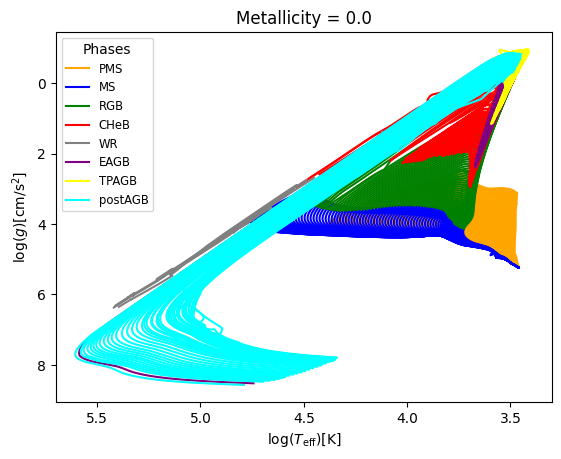

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

In [6]:
print_uniques("star_mass", iso_df)
# print_uniques_count("star_mass", iso_df)

star_mass : 1467117 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
633331,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
633332,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
633333,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
633334,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


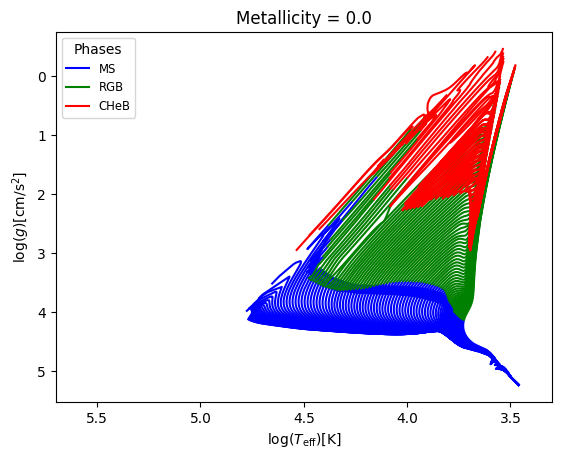

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_uniques("star_mass", phase_filtered_iso_df)
# print_uniques_count("star_mass", phase_filtered_iso_df)

star_mass : 633336 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,6.50,4.126429,4.449033,0.0,-0.25,2.859137,0.222566
1,6.50,4.130406,4.448602,0.0,-0.25,2.900395,0.225872
2,6.50,4.134480,4.448201,0.0,-0.25,2.941695,0.229166
3,6.50,4.138527,4.447853,0.0,-0.25,2.982876,0.232424
4,6.55,4.113582,4.450139,0.0,-0.25,2.734122,0.212411
...,...,...,...,...,...,...,...
323154,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
323155,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
323156,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
323157,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


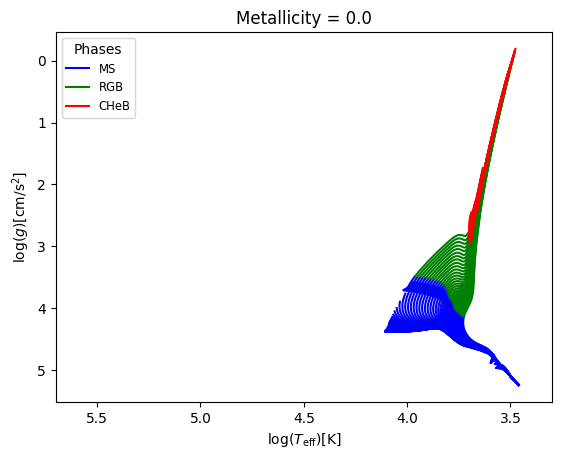

In [9]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], "star_mass" : ("<", 3)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_age_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_age_filtered.plot_Kiel([], [0.0])

In [10]:
print_all_uniques(phase_mass_filtered_iso_df)

log10_isochrone_age_yr  : Range : 6.2 - 10.3, Mean : 9.1042, Median : 9.2

log_Teff  : Range : 3.34 - 5.2138, Mean : 3.8022, Median : 3.7554

log_g  : Range : -1.08 - 7.9405, Mean : 3.6564, Median : 4.1712

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 3.0, Mean : 1.3172, Median : 1.1821

log_R  : Range : -1.86 - 2.7813, Mean : 0.4084, Median : 0.2349



In [11]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 2.9999868374941867
Median value in train data for the star_mass parameter: 1.1814723221045602
Mean value in train data for the star_mass parameter: 1.3167789680474338

Range in train data for the log_R parameter : -1.861069007171269 - 2.772287451333455
Median value in train data for the log_R parameter: 0.2350500595994825
Mean value in train data for the log_R parameter: 0.4079055757762753

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999982496805748 - 2.99979014823184
Median value in test data for the star_mass parameter: 1.183714674060965
Mean value in test data for the star_mass parameter: 1.318589079118794

Range in test data for the log_R parameter : -1.8582211103901525 - 2.7813065611193197
Median value in test data for the log_R parameter: 0.2343205698715712
Mean value in test data for the log_R parameter: 0.409728859663298

(242369, 4) (80790, 4)
(242369

## Model training

### Linear regression

In [12]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.8226816036408051
  RMSE :  0.318923392743888
  MAE :  0.2468843962705581
  MedAE :  0.1981865105082724
  CORR :  0.9082925664189878
  MAX_ER :  1.0632048095338902
  Percentiles : 
    75th percentile :  0.3585533931987852
    90th percentile :  0.5545707055578695
    95th percentile :  0.6637593811171811
    99th percentile :  0.8096067659203992

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.6094803842541214
  RMSE :  0.40795181296848076
  MAE :  0.31283468382588653
  MedAE :  0.25049991044110187
  CORR :  0.8443908629223283
  MAX_ER :  1.286388691281558
  Percentiles : 
    75th percentile :  0.4681774189648824
    90th percentile :  0.6952661554602633
    95th percentile :  0.8413092853514034
    99th percentile :  1.06545714846843

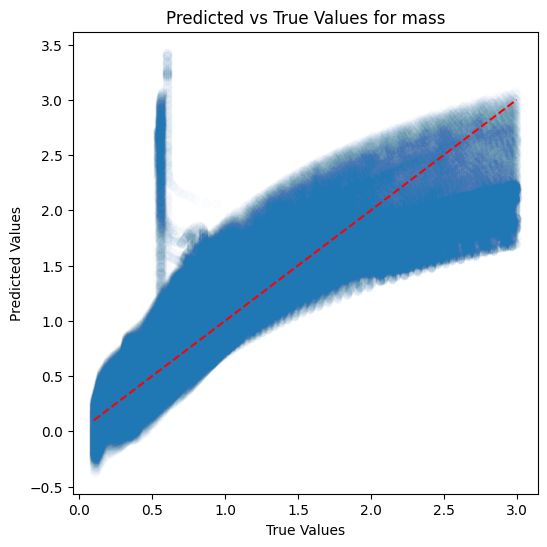

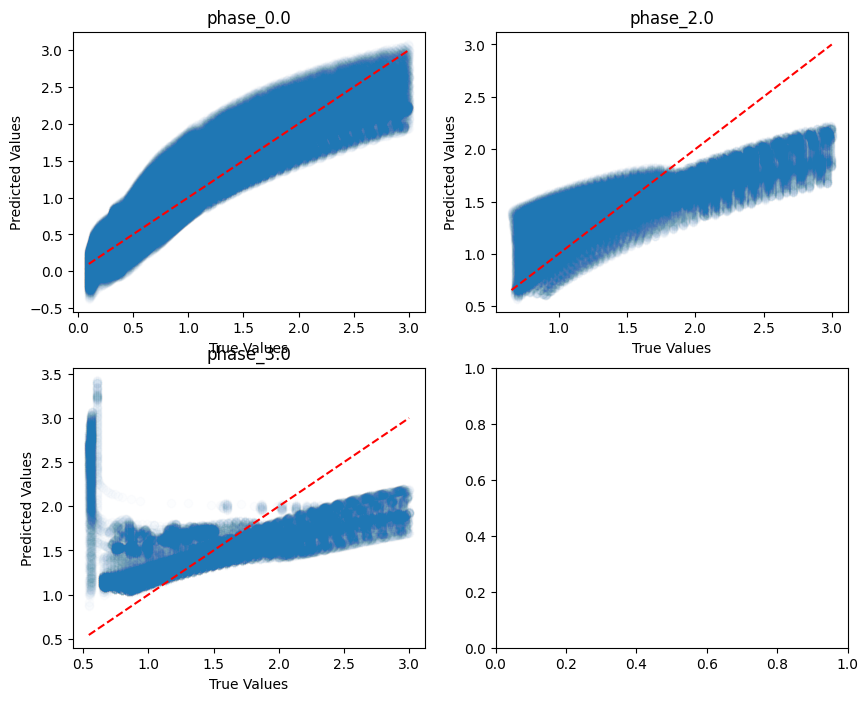

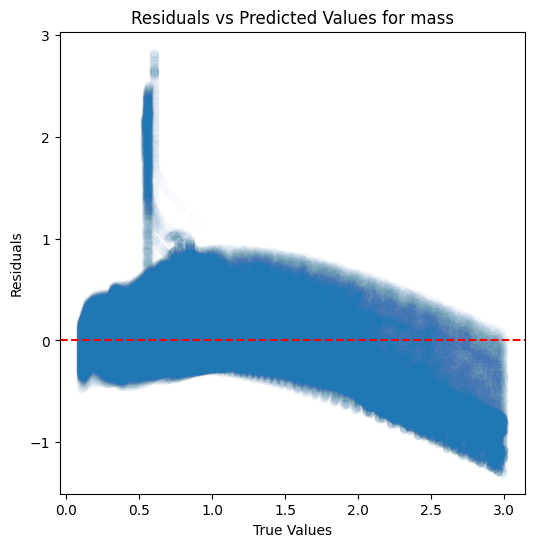

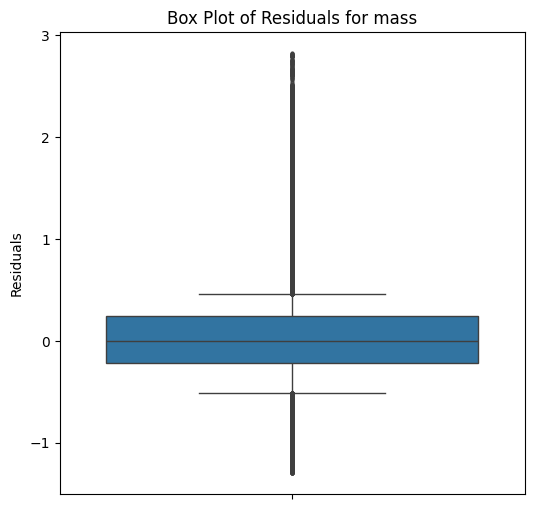

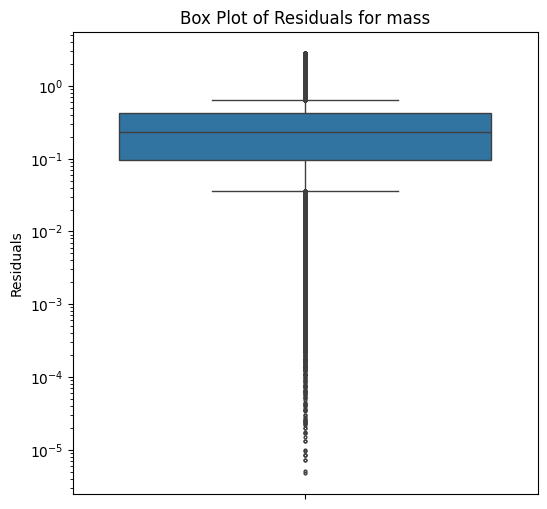

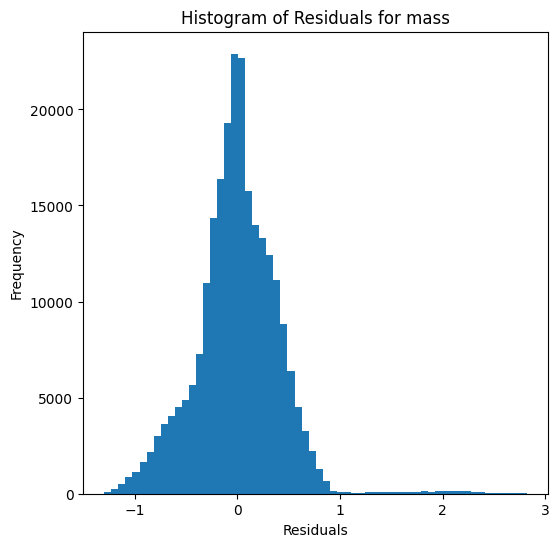

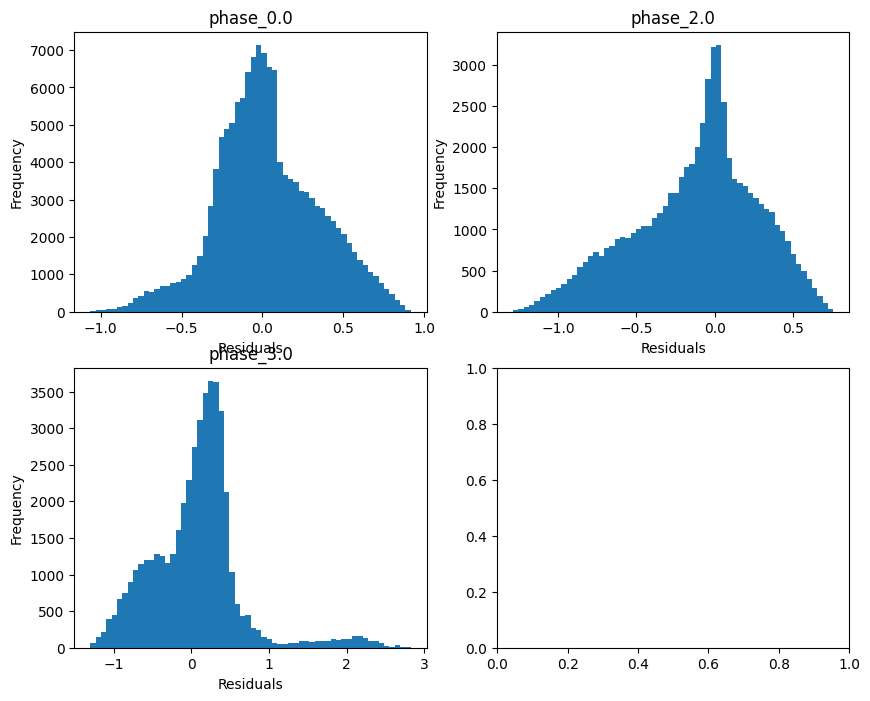

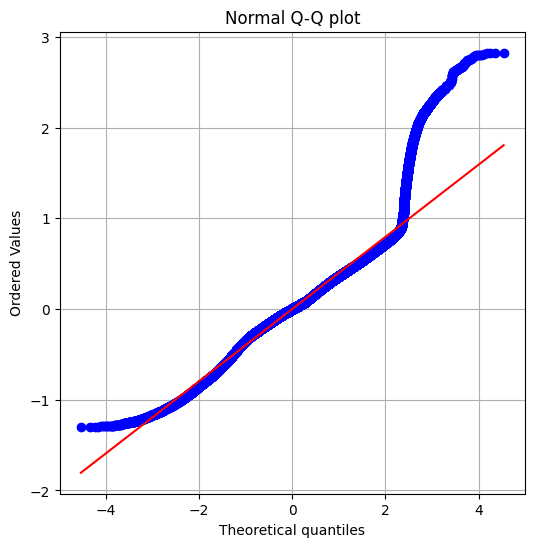

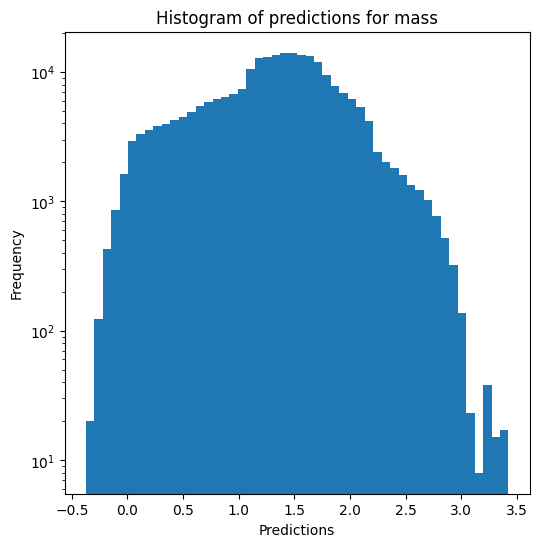

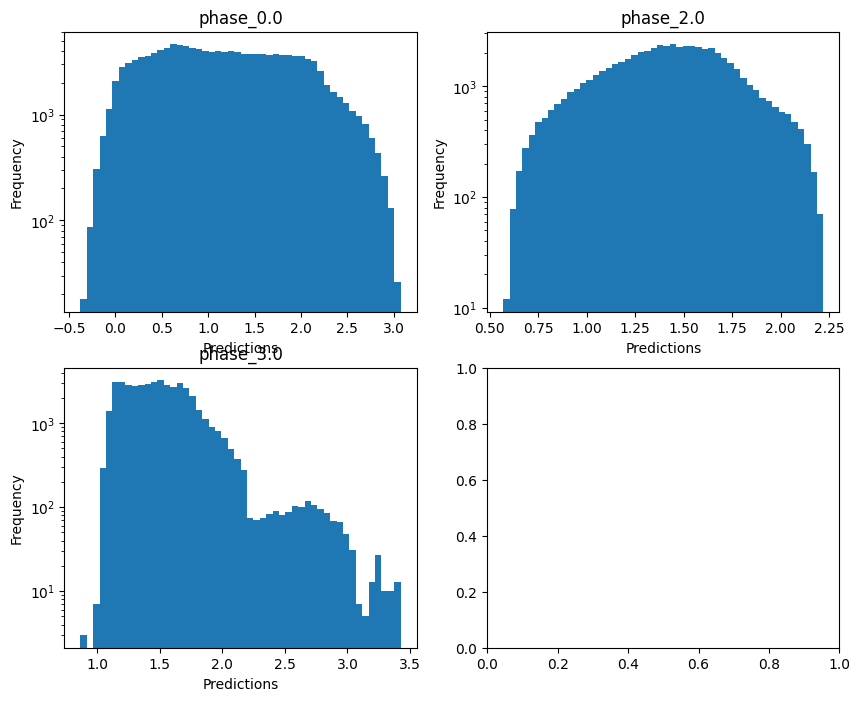

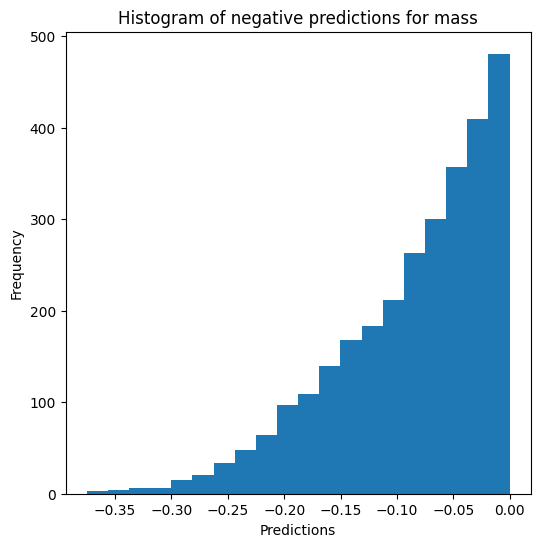


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 0.7629161677552769
  RVE :  0.9597040325540658
  RMSE :  0.0640247338850259
  MAE :  0.04957607165002803
  MedAE :  0.04014195577677965
  CORR :  0.9843634847657234
  MAX_ER :  0.267428950963736
  Percentiles : 
    75th percentile :  0.06434492012540848
    90th percentile :  0.09112640882623287
    95th percentile :  0.12587264179852484
    99th percentile :  0.21494386219834422

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.353416446984946
  RVE :  0.9832984636261459
  RMSE :  0.06269077852580816
  MAE :  0.05305258723034893
  MedAE :  0.046683992102352134
  CORR :  0.9952209519299173
  MAX_ER :  0.1826891264968893
  Percentiles : 
    75th percentile :  0.07504452948630827
    90th percentile :  0.10077730464845724
    95th percentile :  0.11590704064772533
    99th percentile :  0.14029048663308663

radius results for the phase categ

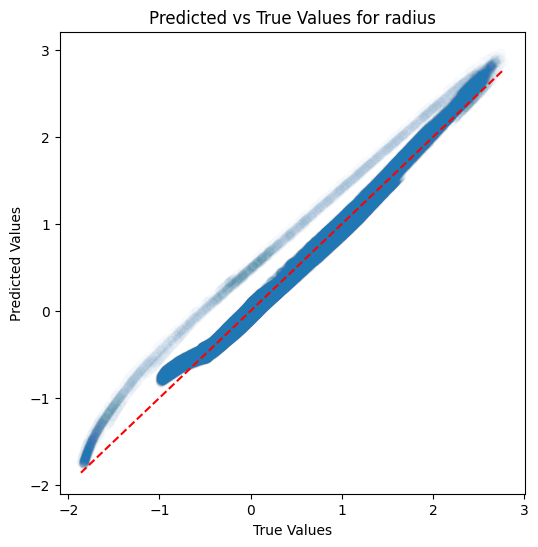

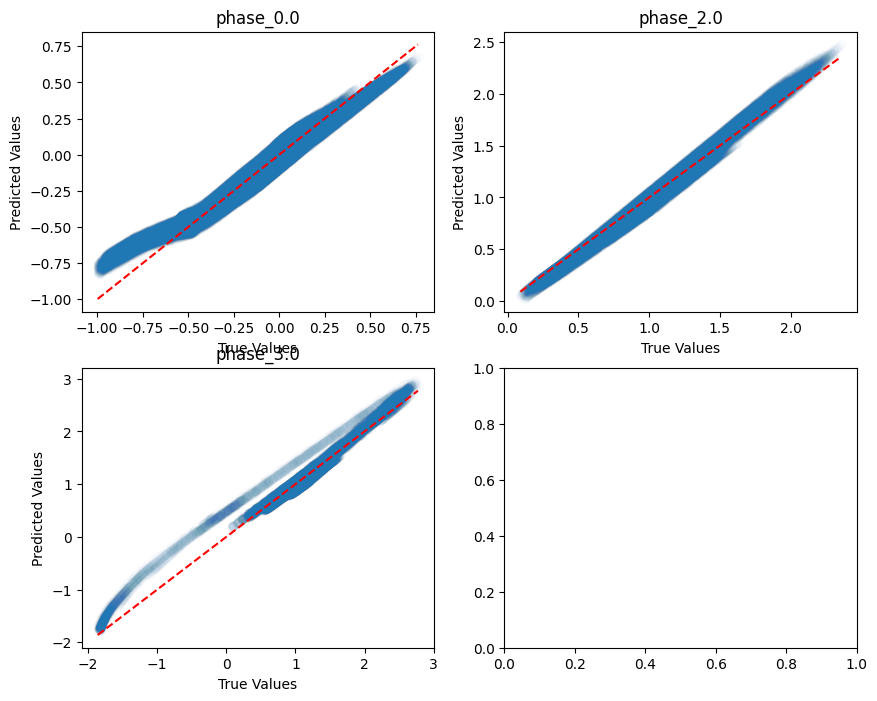

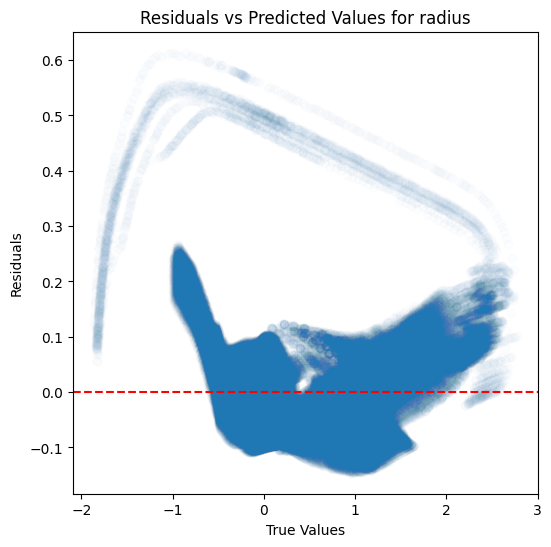

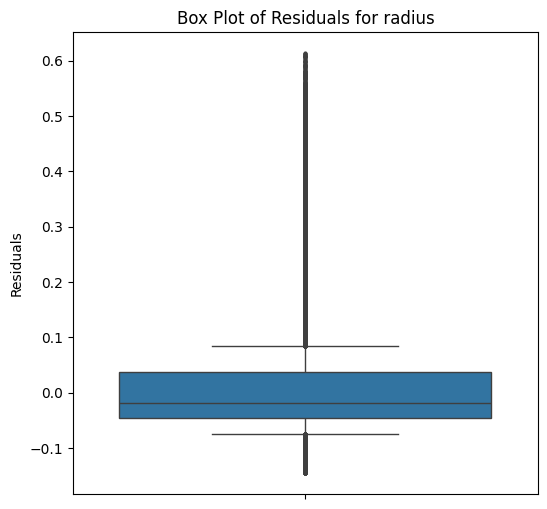

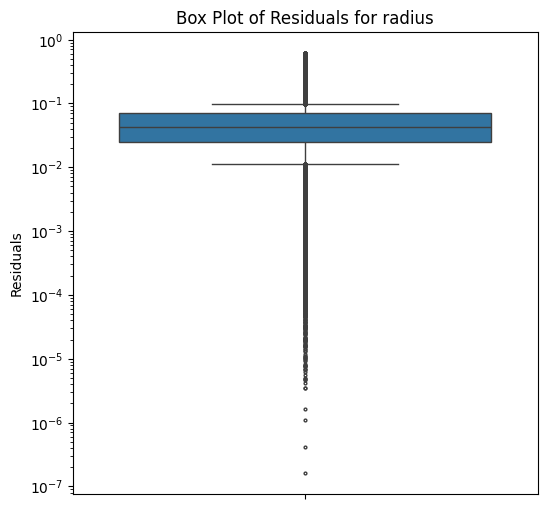

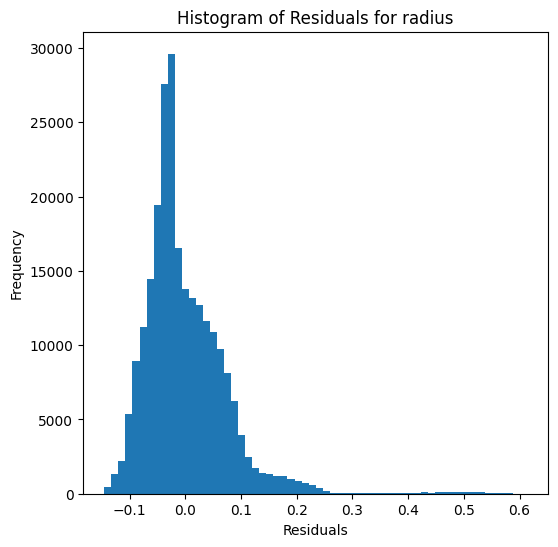

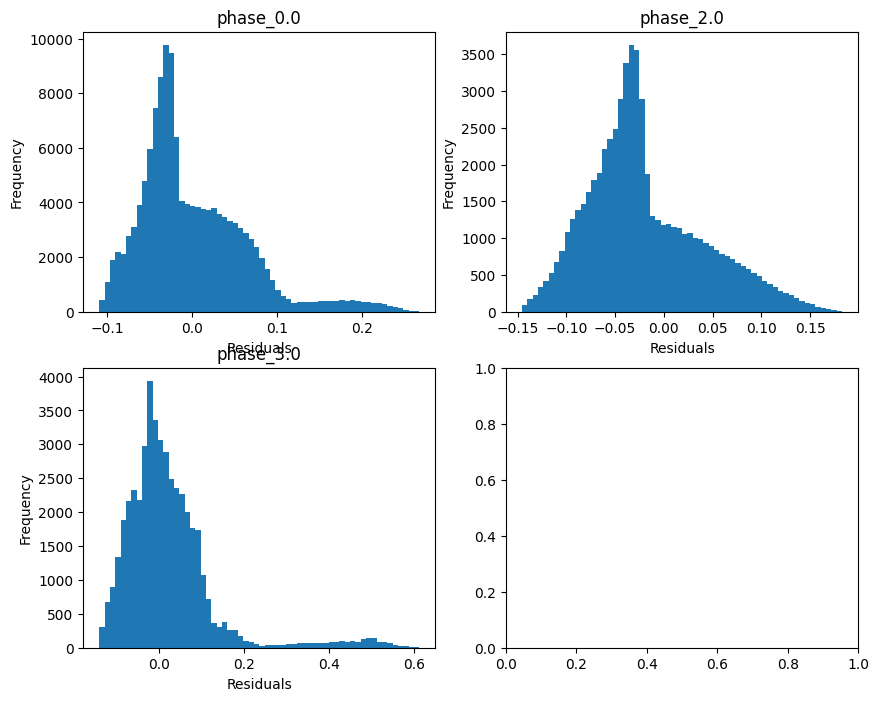

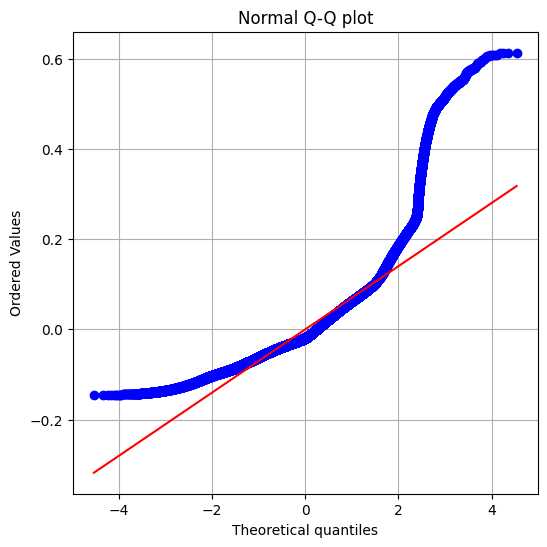

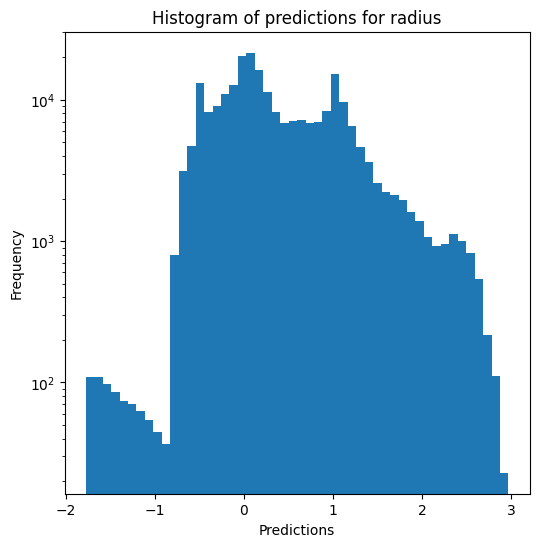

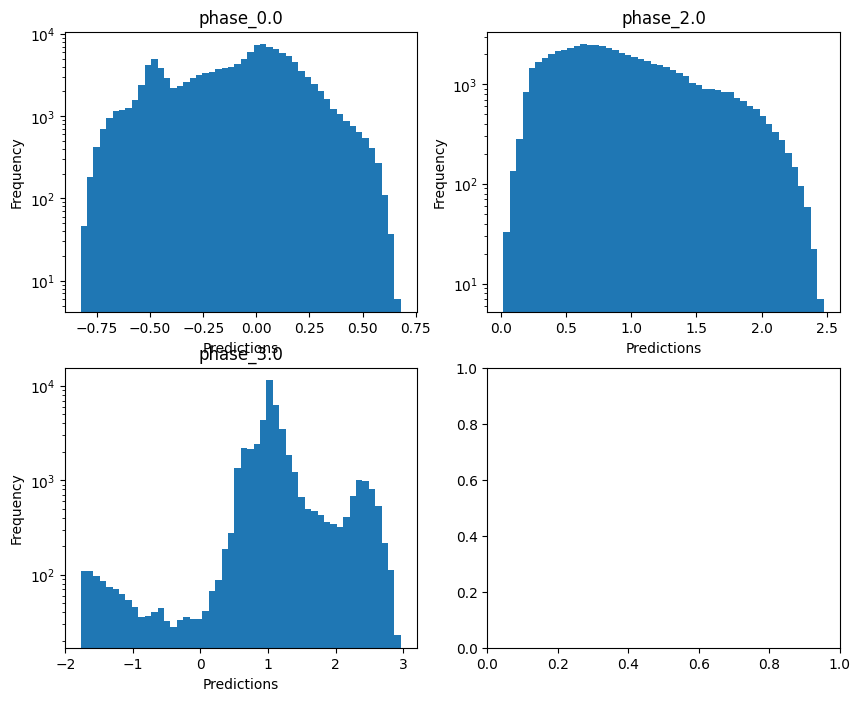

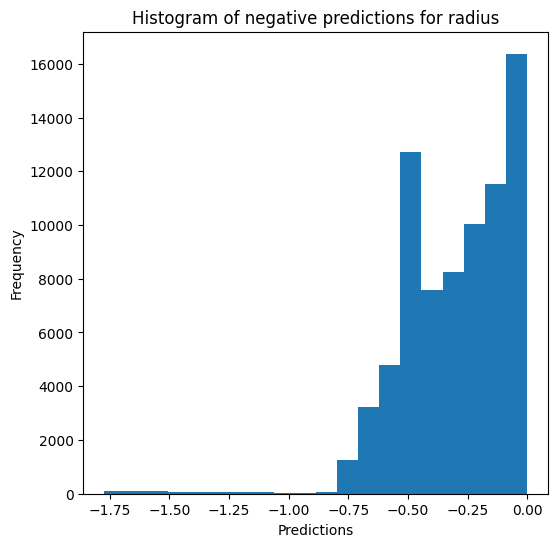

Saving results...


In [13]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True) # override=True, use_preds=False

### Decision tree

In [14]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9998109603044399
  RMSE :  0.010370181942051407
  MAE :  0.005151362084081304
  MedAE :  0.002431496292047308
  CORR :  0.9999054840622302
  MAX_ER :  0.34190413977015777
  Percentiles : 
    75th percentile :  0.005843316720119313
    90th percentile :  0.01193168294680339
    95th percentile :  0.01927284534971138
    99th percentile :  0.04066194991115503

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9992078967946935
  RMSE :  0.017616715482776626
  MAE :  0.007694368270985248
  MedAE :  0.0011683880009409897
  CORR :  0.9996086734847093
  MAX_ER :  0.4249228172899455
  Percentiles : 
    75th percentile :  0.008360639195317487
    90th percentile :  0.02499243299335696
    95th percentile :  0.0344050462943411

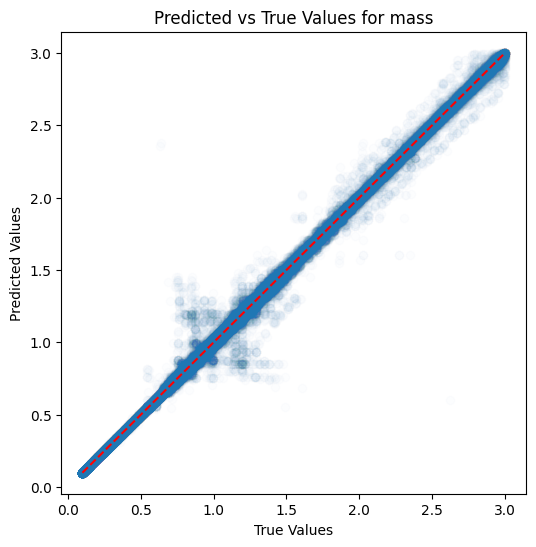

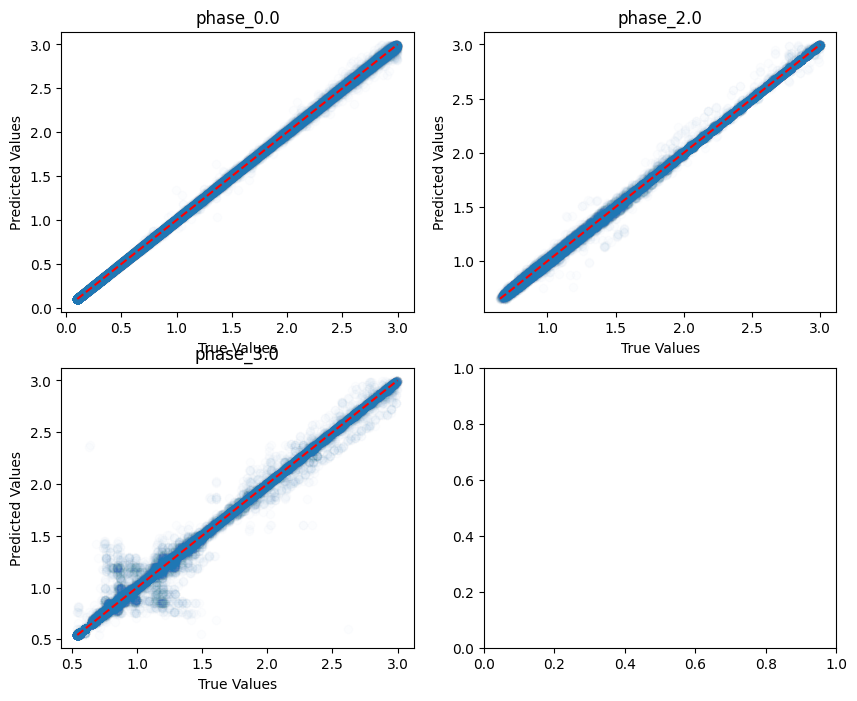

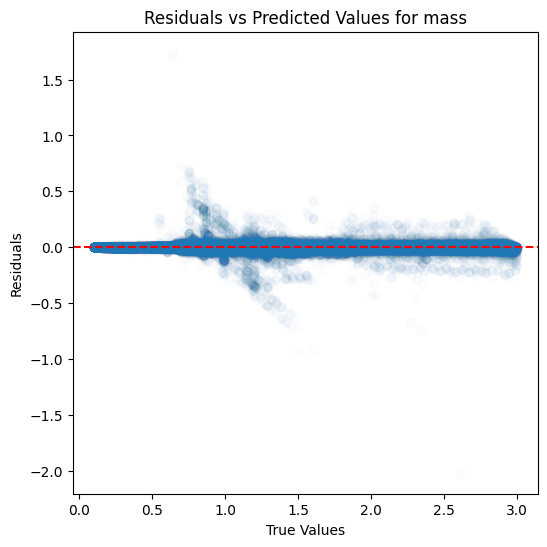

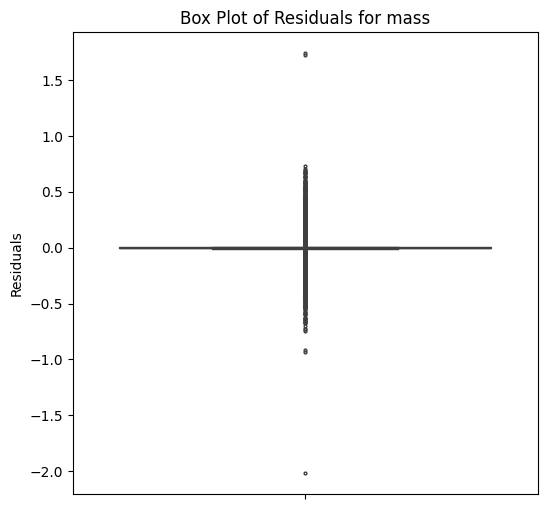

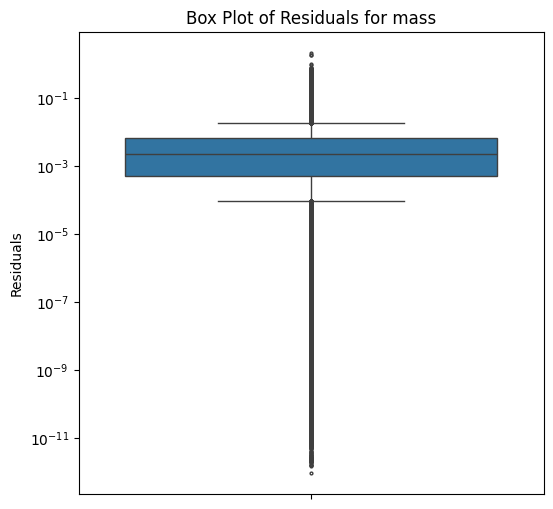

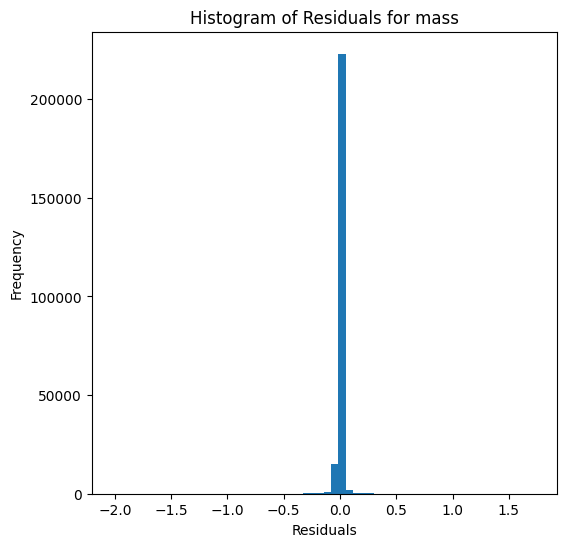

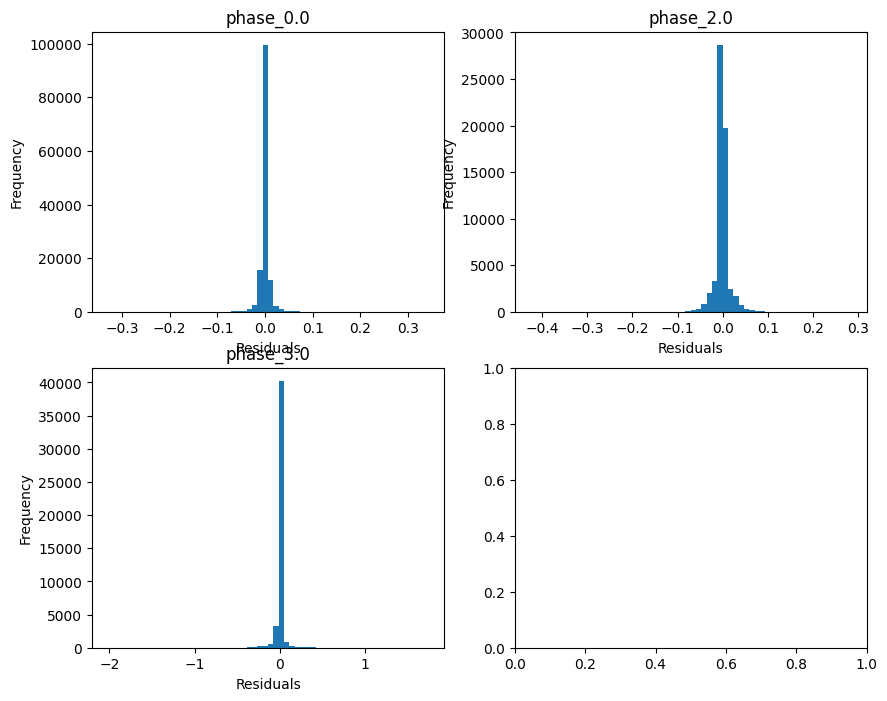

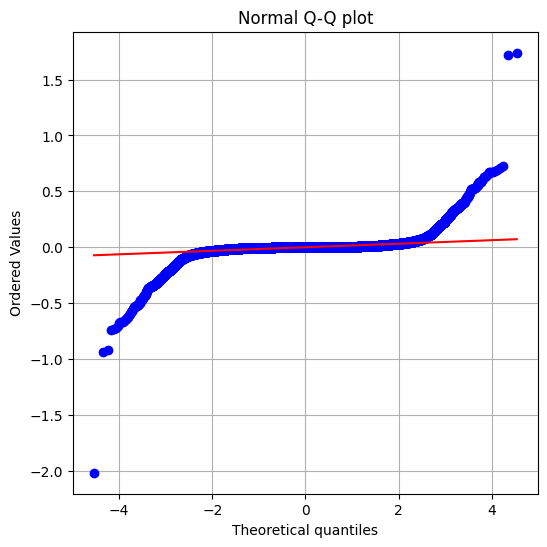

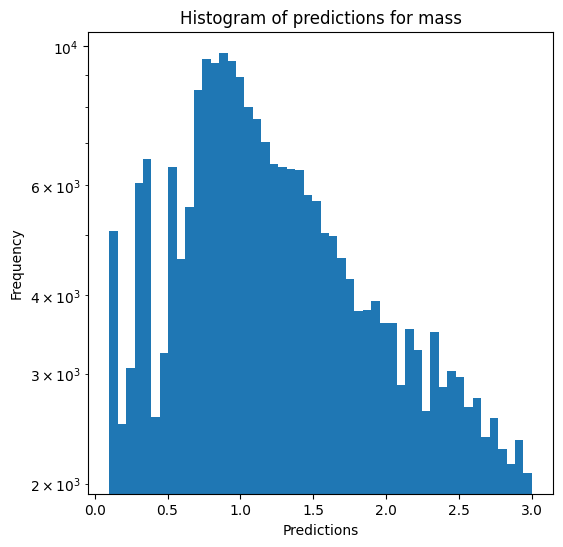

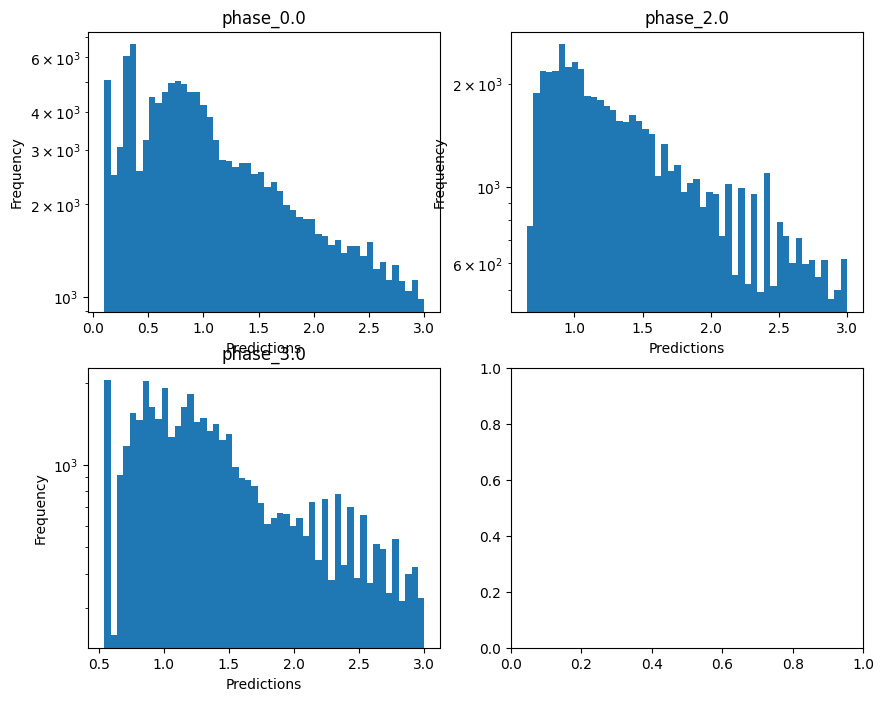


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 0.7629161677552769
  RVE :  0.9998320816205213
  RMSE :  0.0041347289814373175
  MAE :  0.002637829554723163
  MedAE :  0.0017520001969897891
  CORR :  0.9999160804490097
  MAX_ER :  0.12423453457943151
  Percentiles : 
    75th percentile :  0.0034804982820658
    90th percentile :  0.005653801985096046
    95th percentile :  0.007711756635804636
    99th percentile :  0.01497666970129874

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.353416446984946
  RVE :  0.9995587617625535
  RMSE :  0.009659532702665367
  MAE :  0.007179036722301516
  MedAE :  0.005917559811051132
  CORR :  0.999779478999035
  MAX_ER :  0.11891552138317962
  Percentiles : 
    75th percentile :  0.010985675613782914
    90th percentile :  0.013937585518692064
    95th percentile :  0.016310658388228982
    99th percentile :  0.028939398282080215

radius results for 

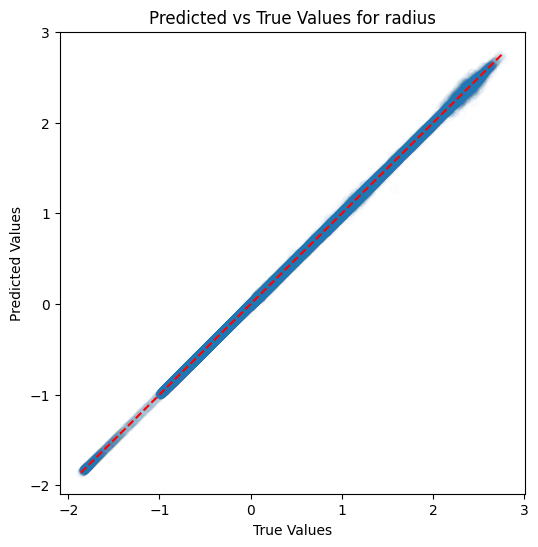

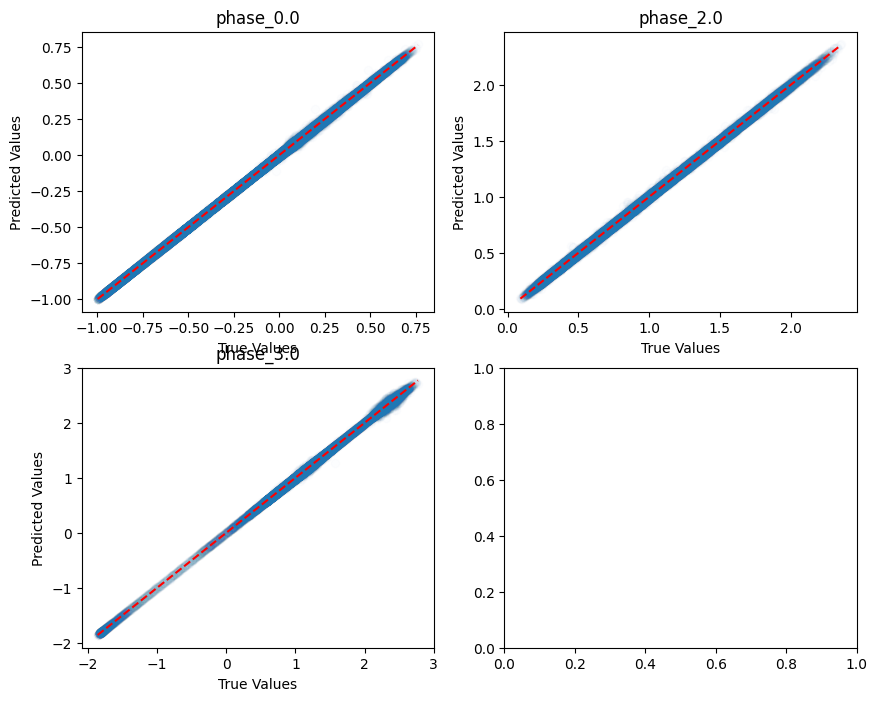

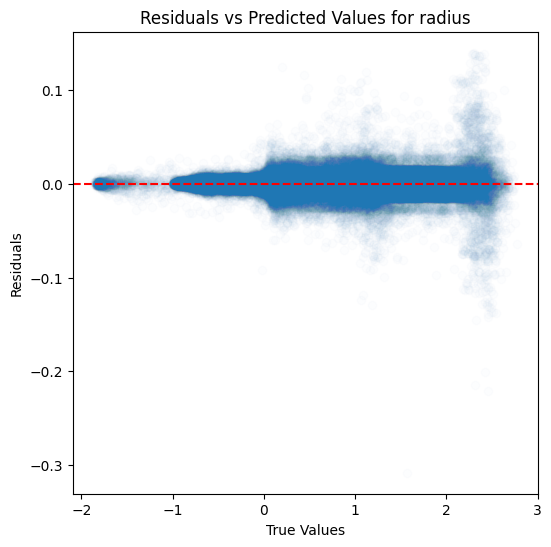

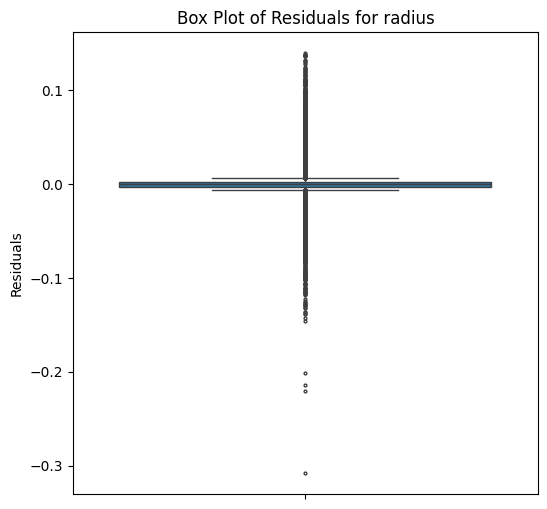

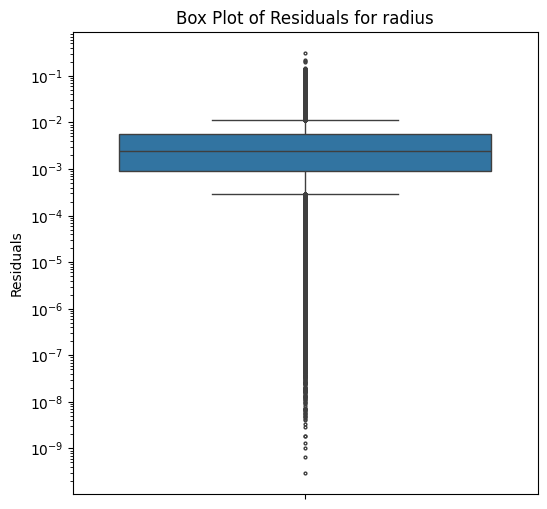

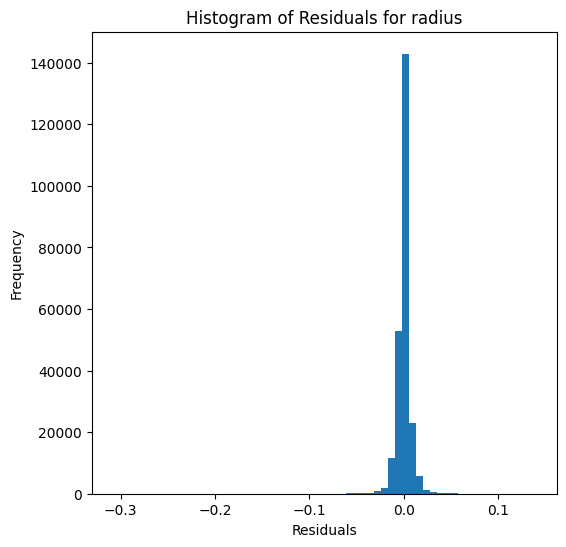

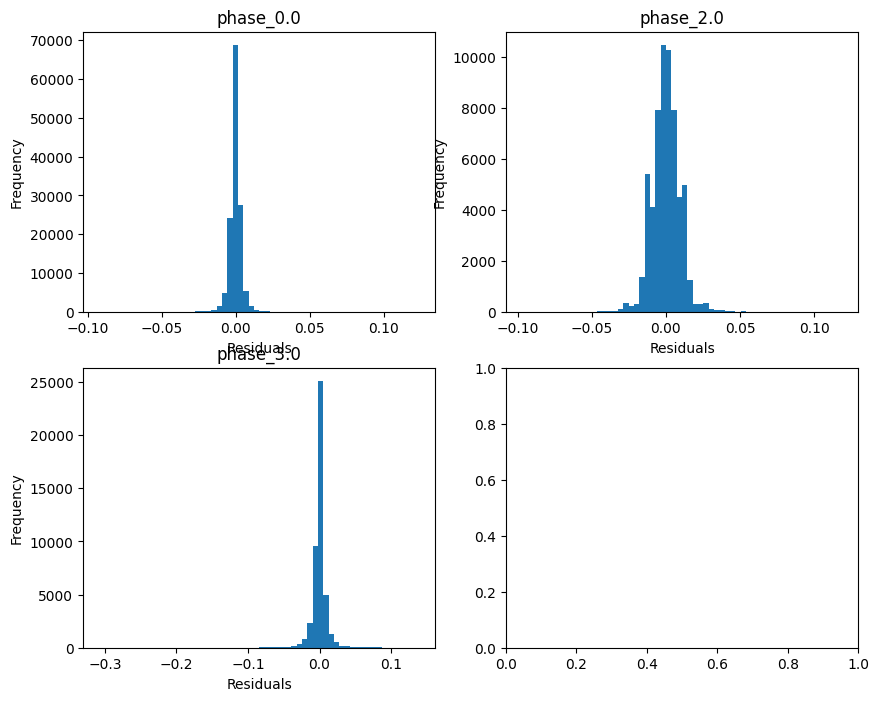

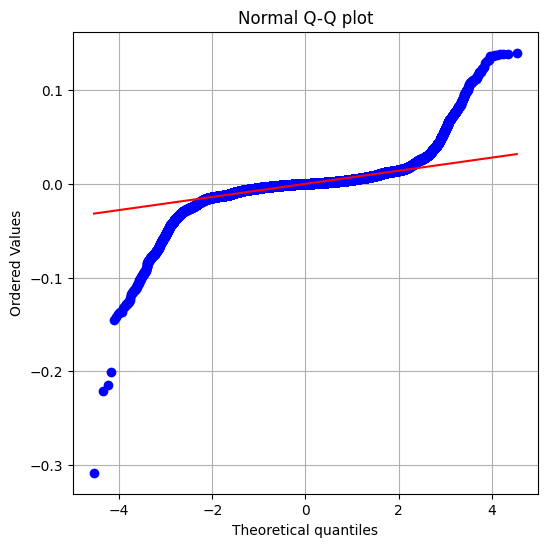

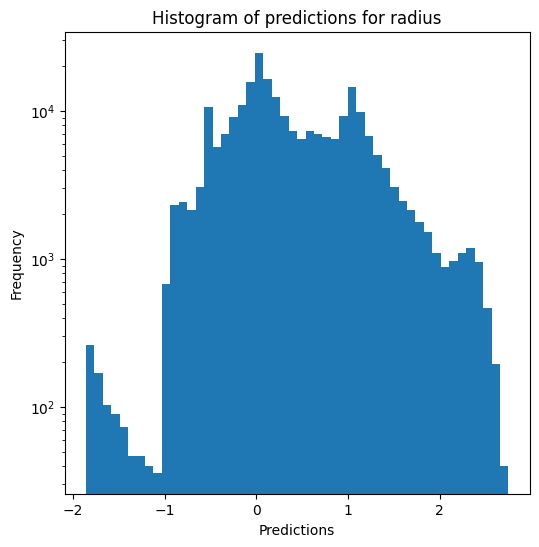

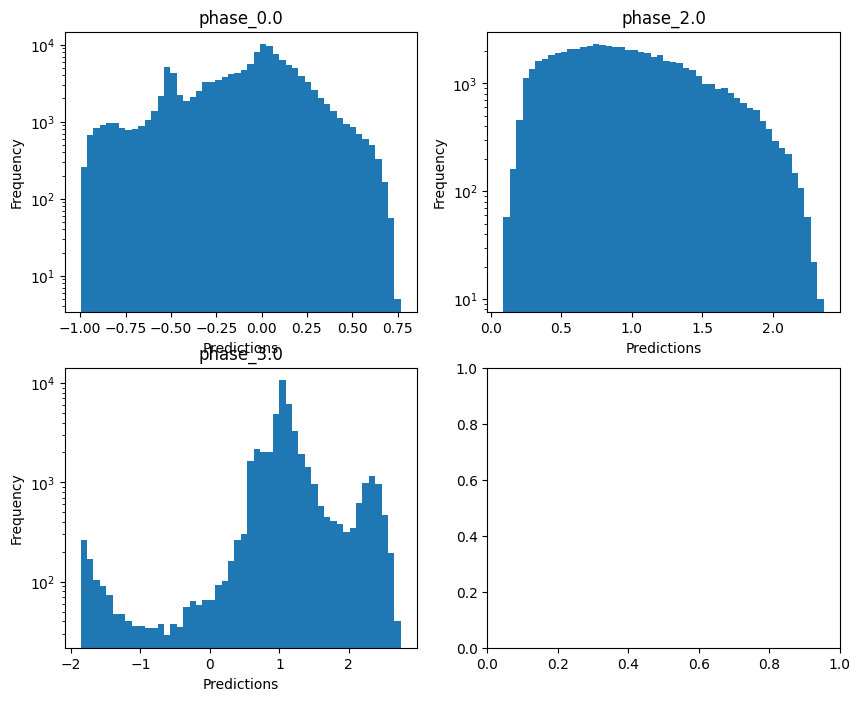

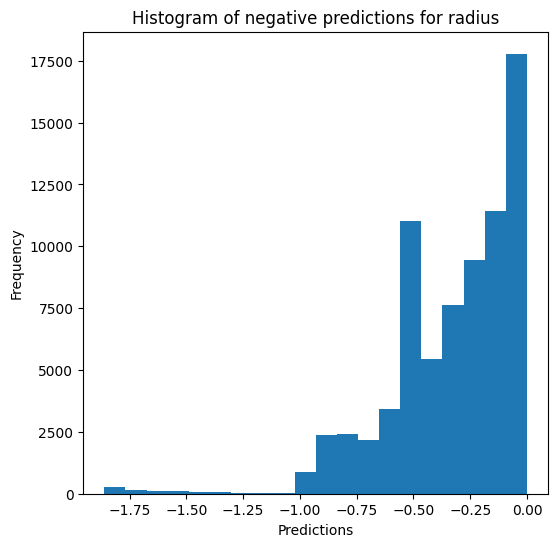

Saving results...


In [15]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True)

### K-nearest neighbours

In [16]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9992443930168096
  RMSE :  0.02073170340400842
  MAE :  0.009679770503752662
  MedAE :  0.004370990974717159
  CORR :  0.9996260930156877
  MAX_ER :  0.3698302020229671
  Percentiles : 
    75th percentile :  0.010528155351717472
    90th percentile :  0.021829590223973724
    95th percentile :  0.0343361761204356
    99th percentile :  0.09292328493384927

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9991876883590323
  RMSE :  0.017863580890469438
  MAE :  0.008954045678879998
  MedAE :  0.0049844695910198356
  CORR :  0.9996103334674206
  MAX_ER :  0.25092821324204007
  Percentiles : 
    75th percentile :  0.011354209287086858
    90th percentile :  0.02133559541576835
    95th percentile :  0.03077397934546
  

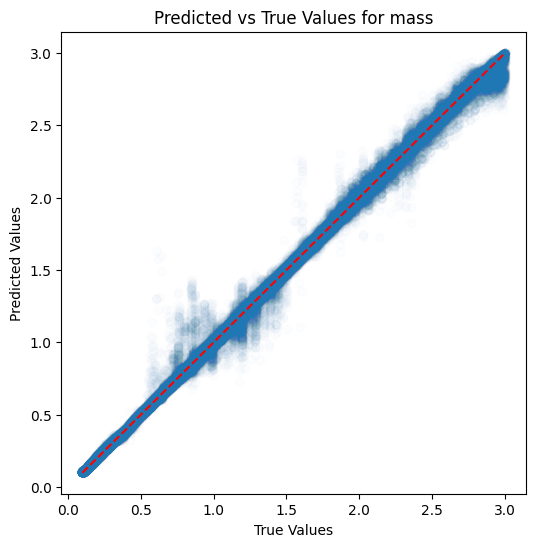

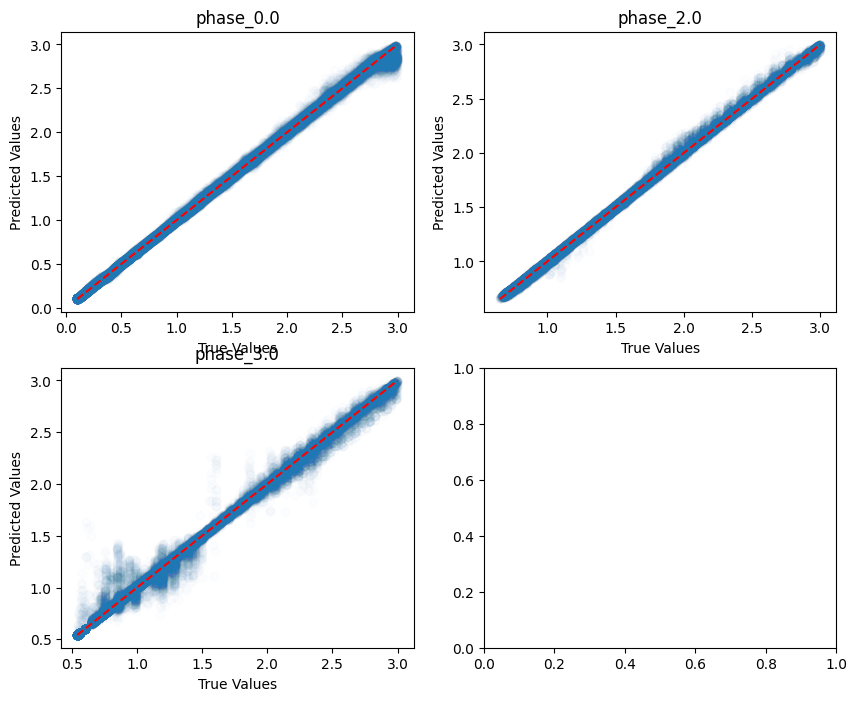

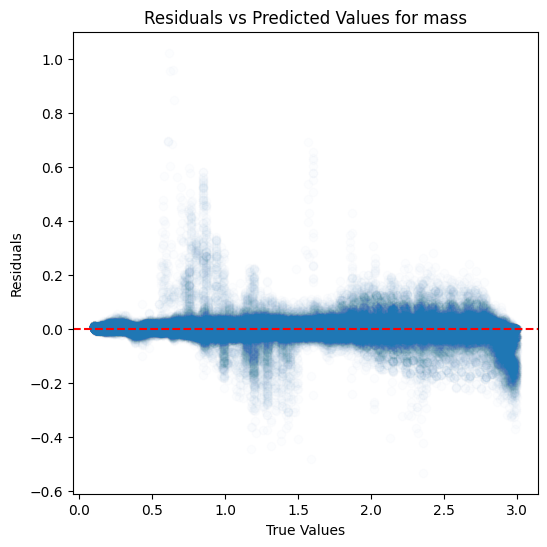

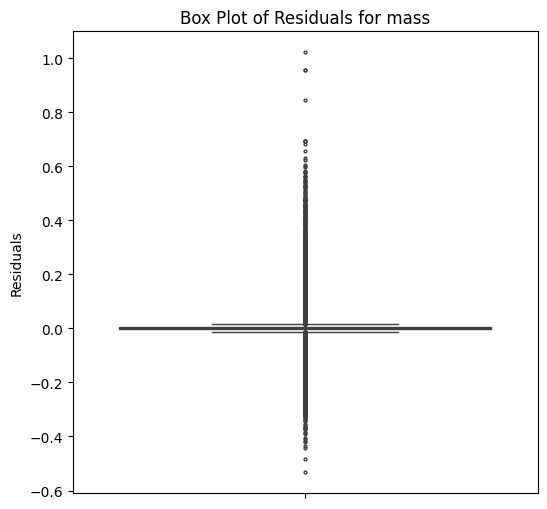

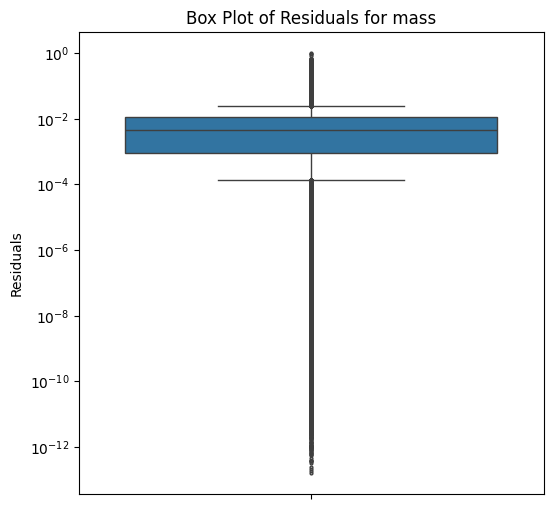

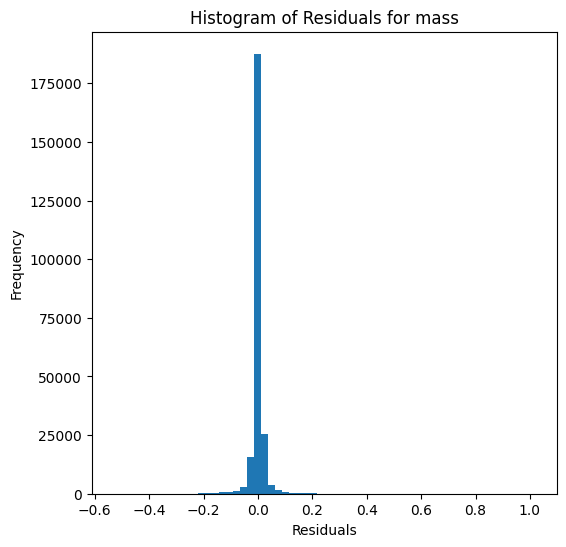

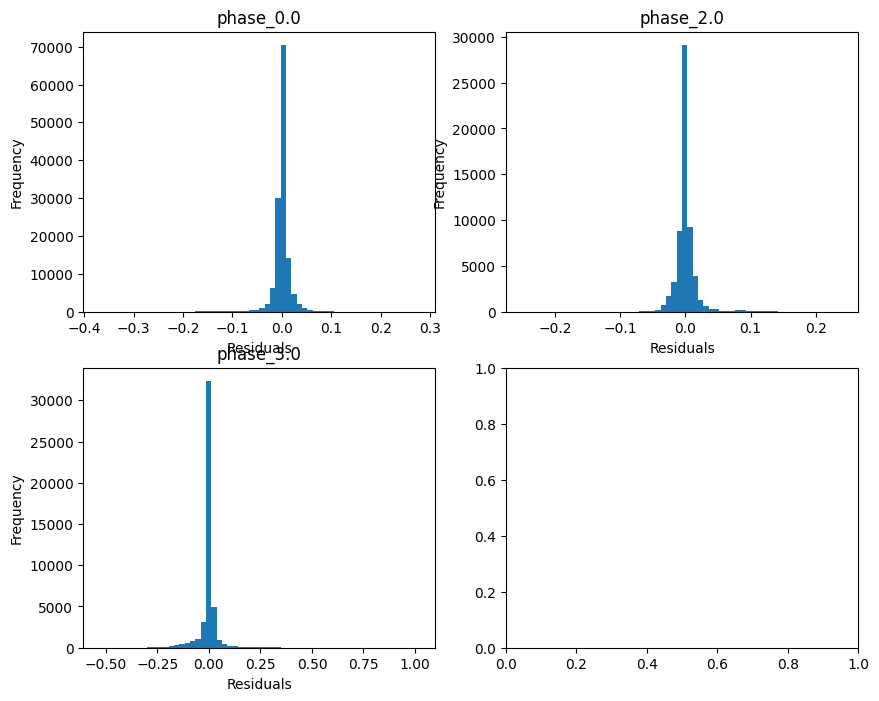

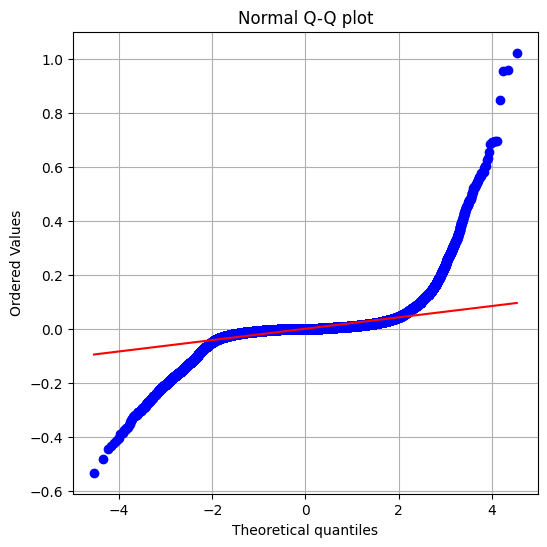

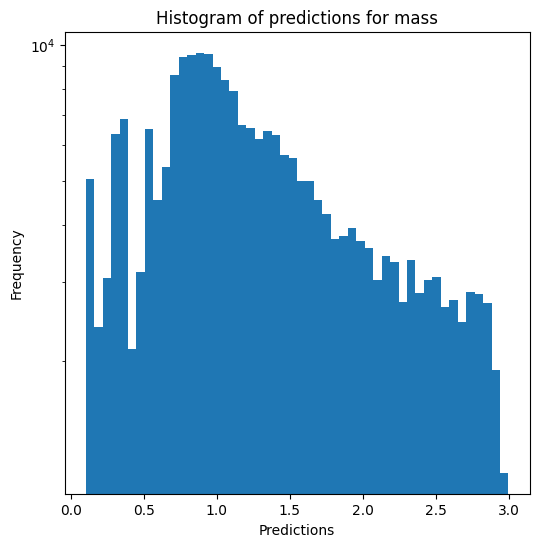

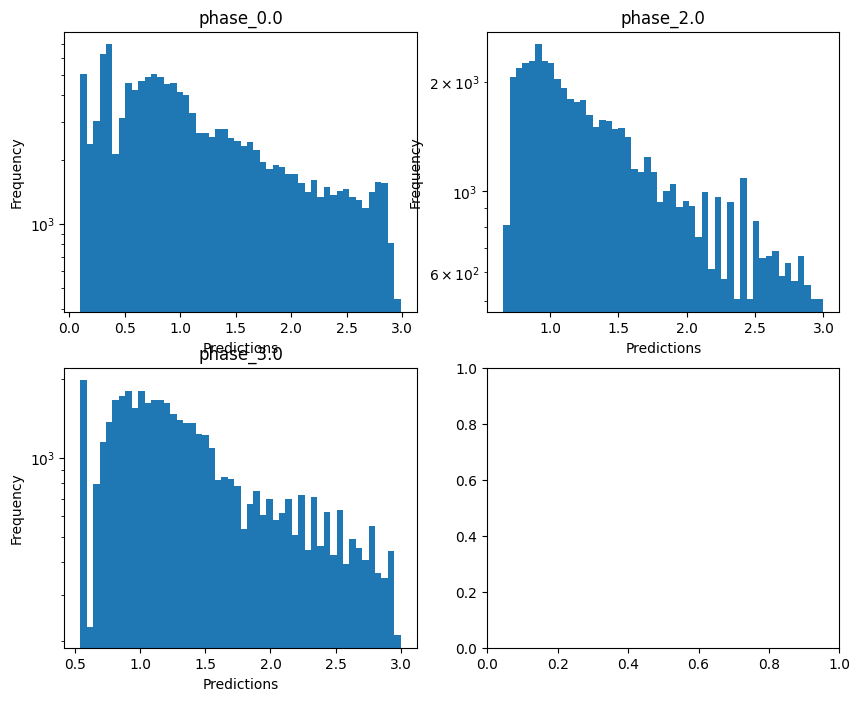


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 0.7629161677552769
  RVE :  0.9996595379770277
  RMSE :  0.005885135279400312
  MAE :  0.0038425086261424522
  MedAE :  0.002375727073808065
  CORR :  0.9998319415121707
  MAX_ER :  0.09194672527837028
  Percentiles : 
    75th percentile :  0.004845554670563537
    90th percentile :  0.009013839957474
    95th percentile :  0.012678134348731338
    99th percentile :  0.02171950930392817

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.353416446984946
  RVE :  0.9998817172665754
  RMSE :  0.005001276314588465
  MAE :  0.003852158053551234
  MedAE :  0.0030662762462867477
  CORR :  0.9999409608872045
  MAX_ER :  0.06103219438058893
  Percentiles : 
    75th percentile :  0.0053024660085946584
    90th percentile :  0.008197831578916293
    95th percentile :  0.010045904288472324
    99th percentile :  0.01406196902269025

radius results for 

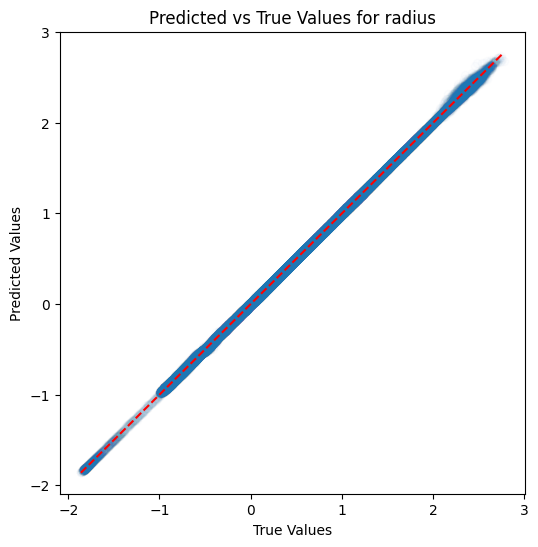

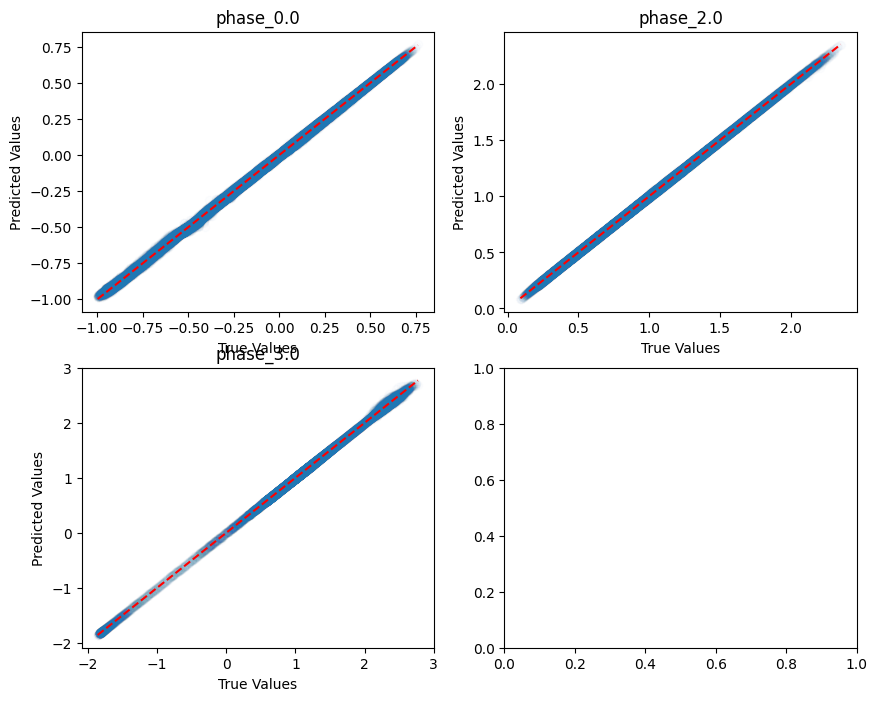

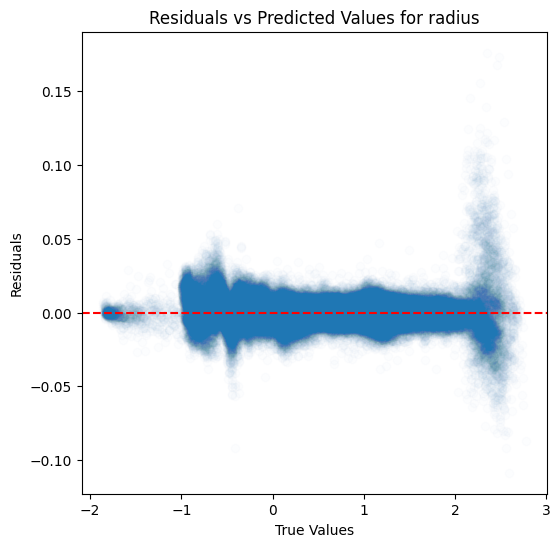

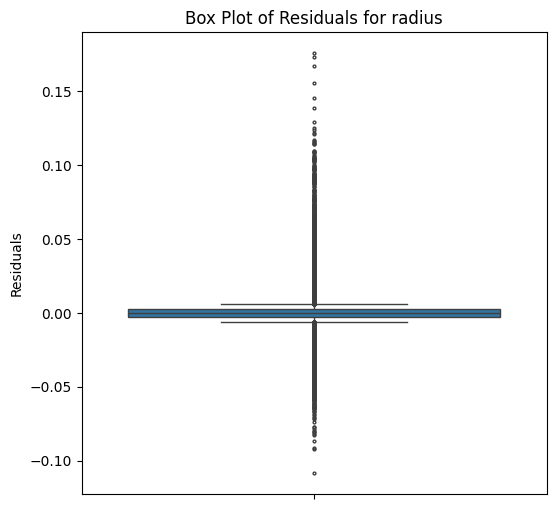

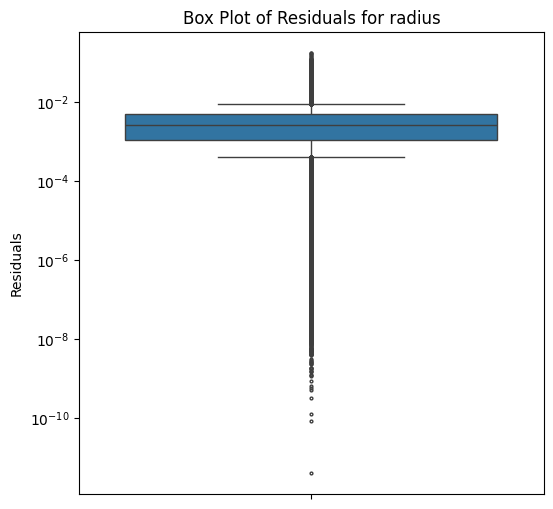

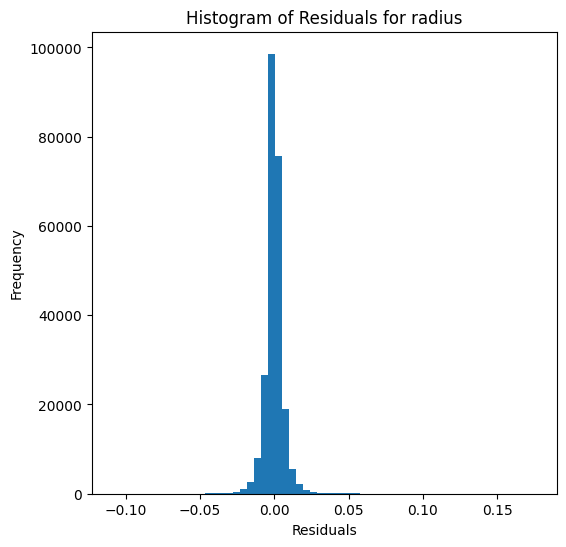

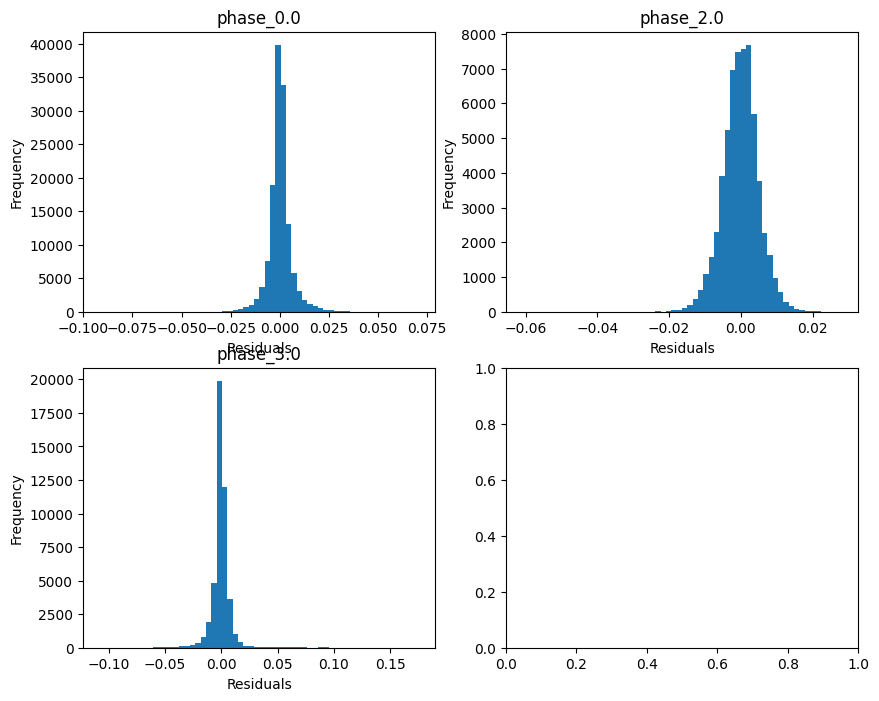

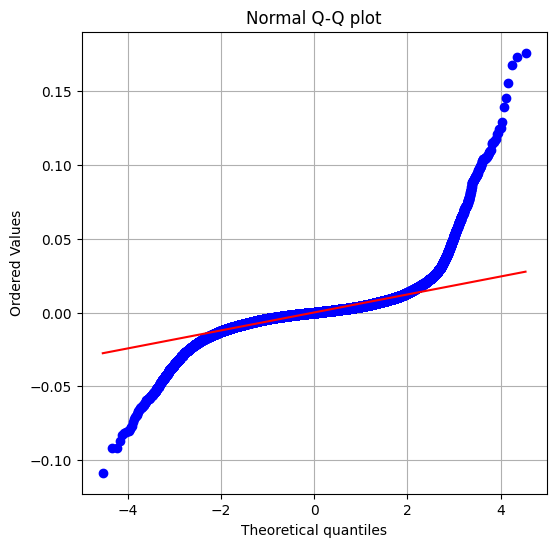

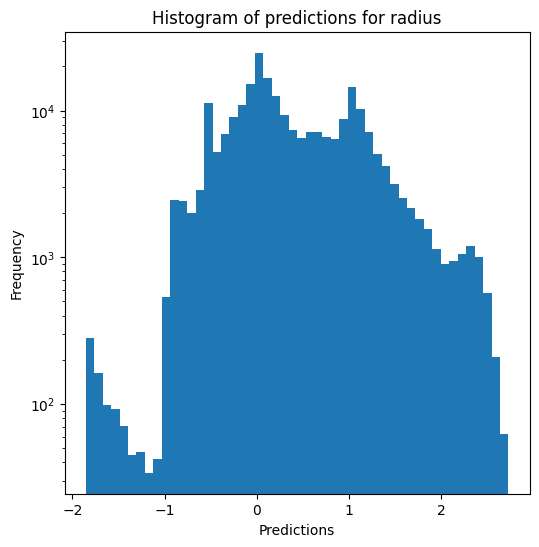

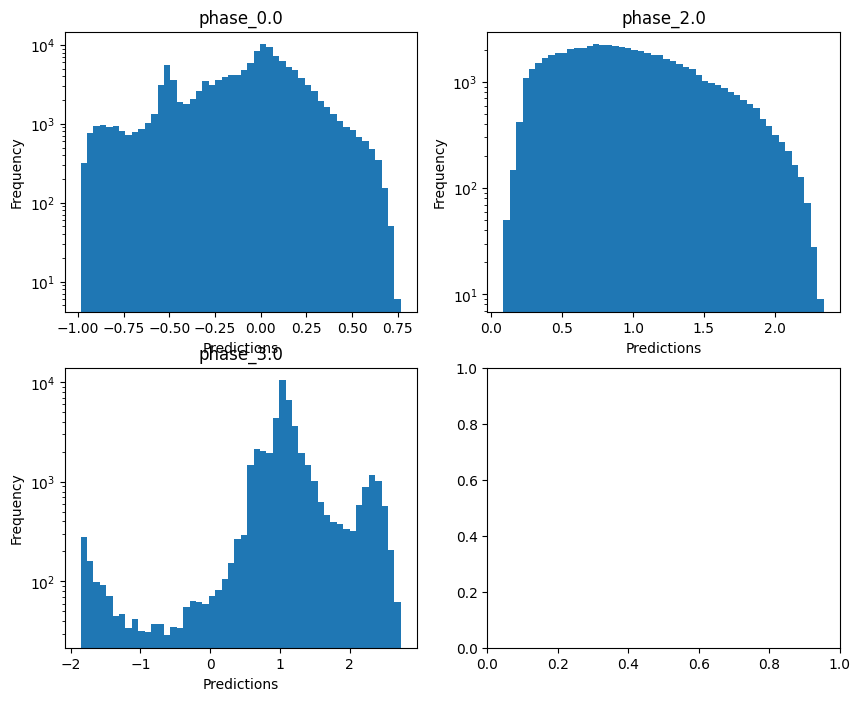

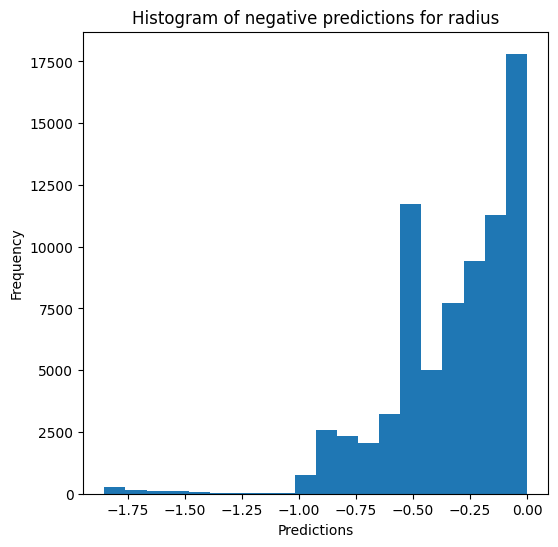

Saving results...


In [17]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True)

### Random forests

In [18]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.999947044394285
  RMSE :  0.005488828615455466
  MAE :  0.002764338682723445
  MedAE :  0.0013470803912696283
  CORR :  0.9999735435321911
  MAX_ER :  0.18157378789633682
  Percentiles : 
    75th percentile :  0.0031892579673771793
    90th percentile :  0.006456650966881172
    95th percentile :  0.009709123296335309
    99th percentile :  0.021790145307659256

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9996653648909077
  RMSE :  0.01145266644937612
  MAE :  0.006816718583654214
  MedAE :  0.004307804055038389
  CORR :  0.9998368427876034
  MAX_ER :  0.2152611485477416
  Percentiles : 
    75th percentile :  0.009034085757285537
    90th percentile :  0.015234223159450444
    95th percentile :  0.0203982234449

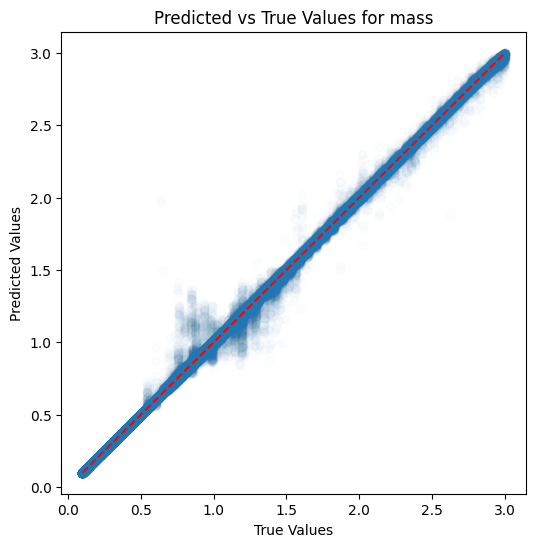

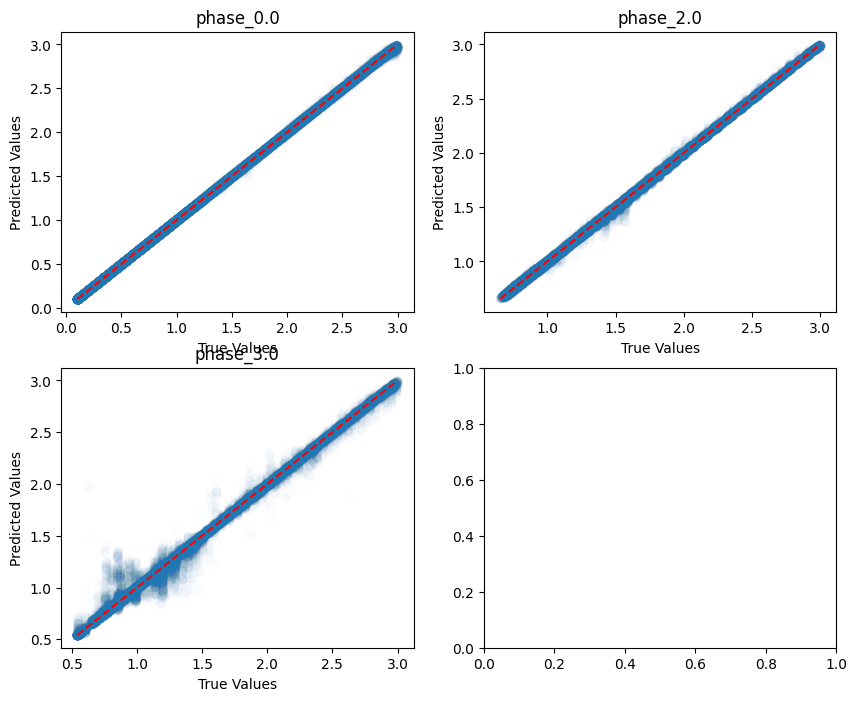

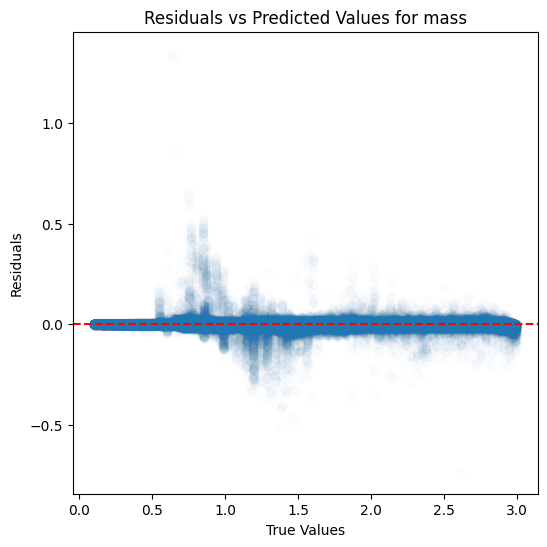

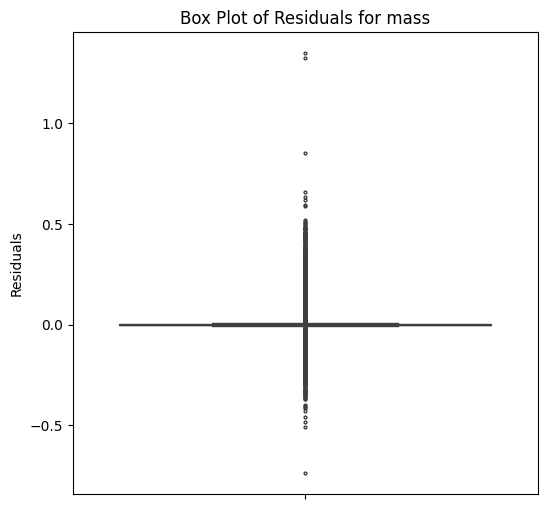

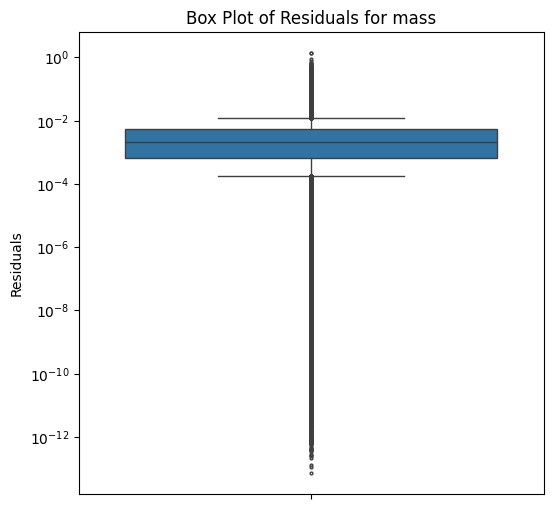

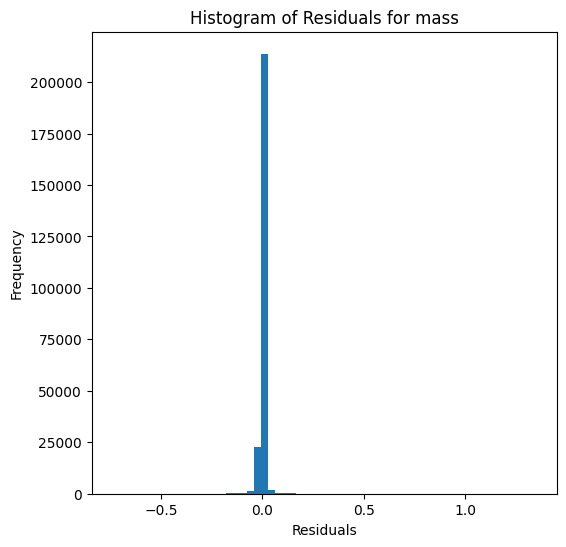

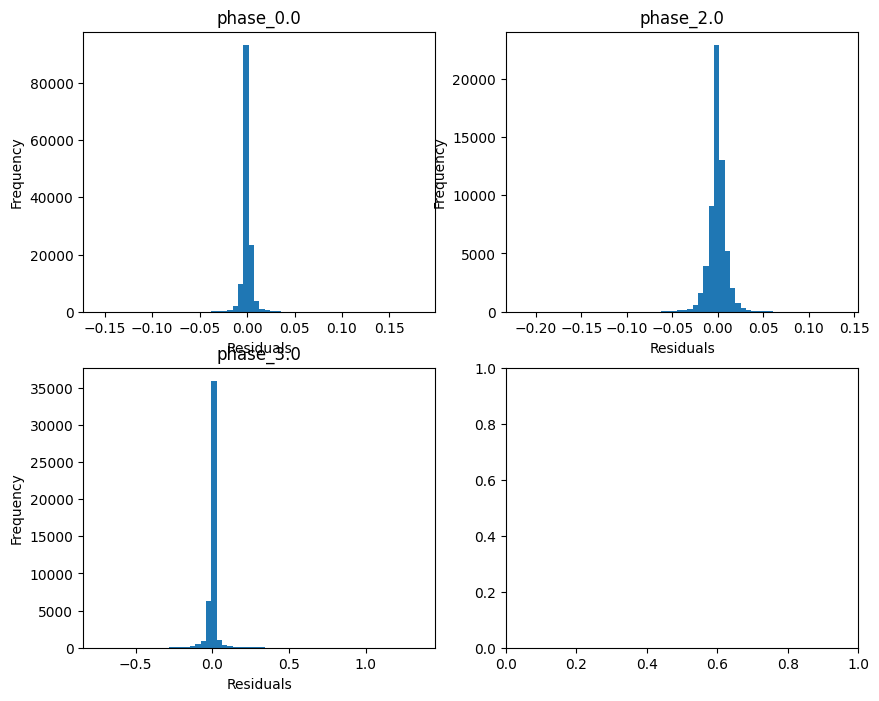

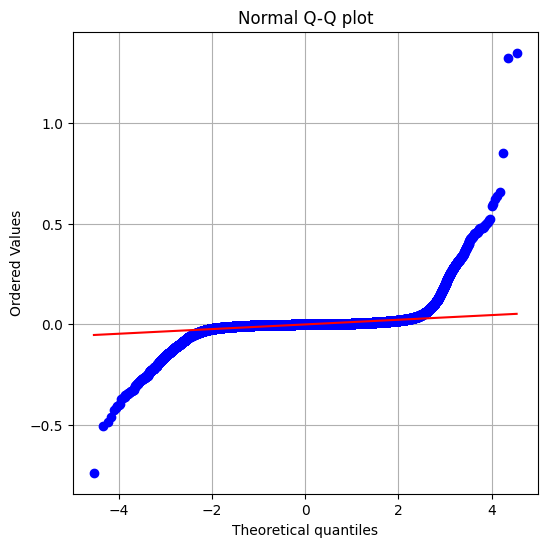

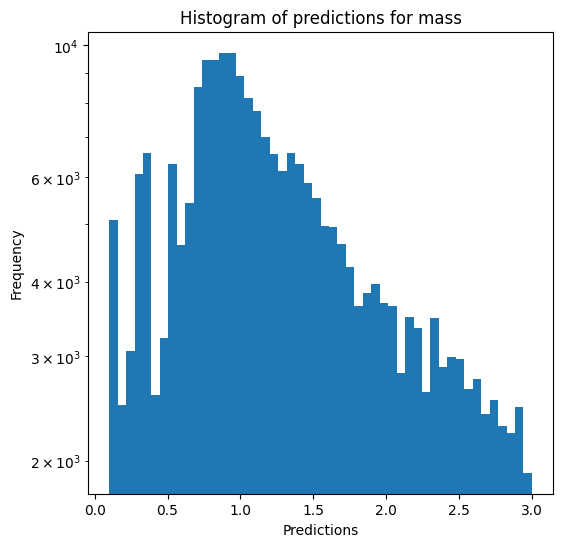

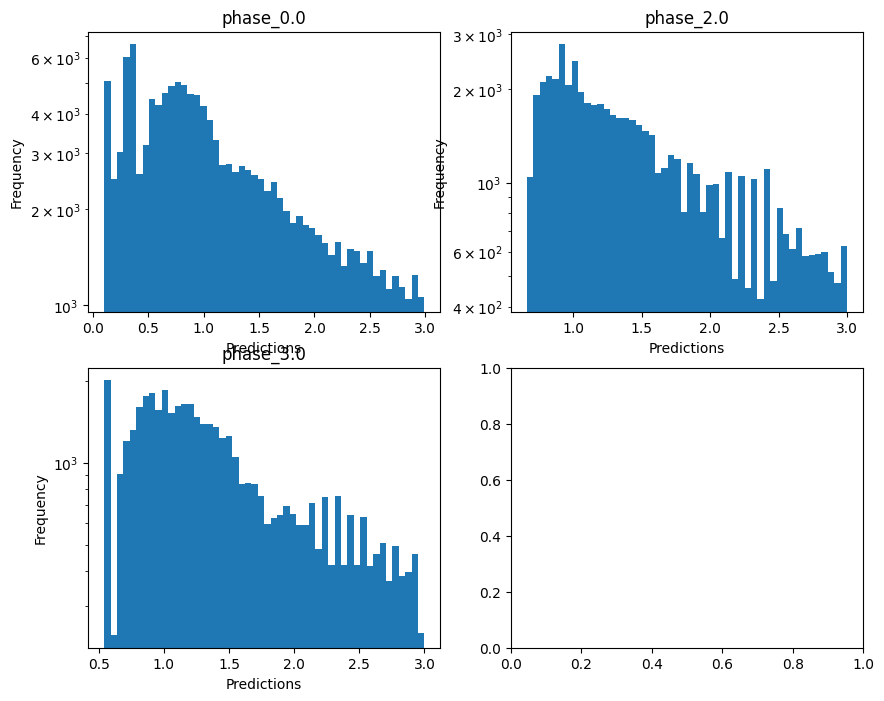


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 0.7629161677552769
  RVE :  0.9999695283084309
  RMSE :  0.0017647987667890634
  MAE :  0.0011131576219897057
  MedAE :  0.0006941944452366622
  CORR :  0.9999848661853572
  MAX_ER :  0.033817034806178314
  Percentiles : 
    75th percentile :  0.0014306878916498025
    90th percentile :  0.0025437538479202103
    95th percentile :  0.003520964944308354
    99th percentile :  0.006483541795234151

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.353416446984946
  RVE :  0.9999391726462705
  RMSE :  0.003588105645084922
  MAE :  0.0025324195768070693
  MedAE :  0.001805420067699126
  CORR :  0.9999695861358541
  MAX_ER :  0.044718073403115066
  Percentiles : 
    75th percentile :  0.0034731743667720805
    90th percentile :  0.005673774923605102
    95th percentile :  0.007347405732167744
    99th percentile :  0.01147145611759324

radius re

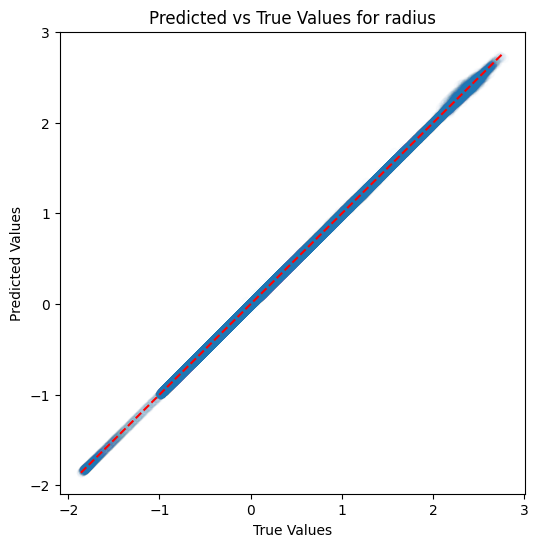

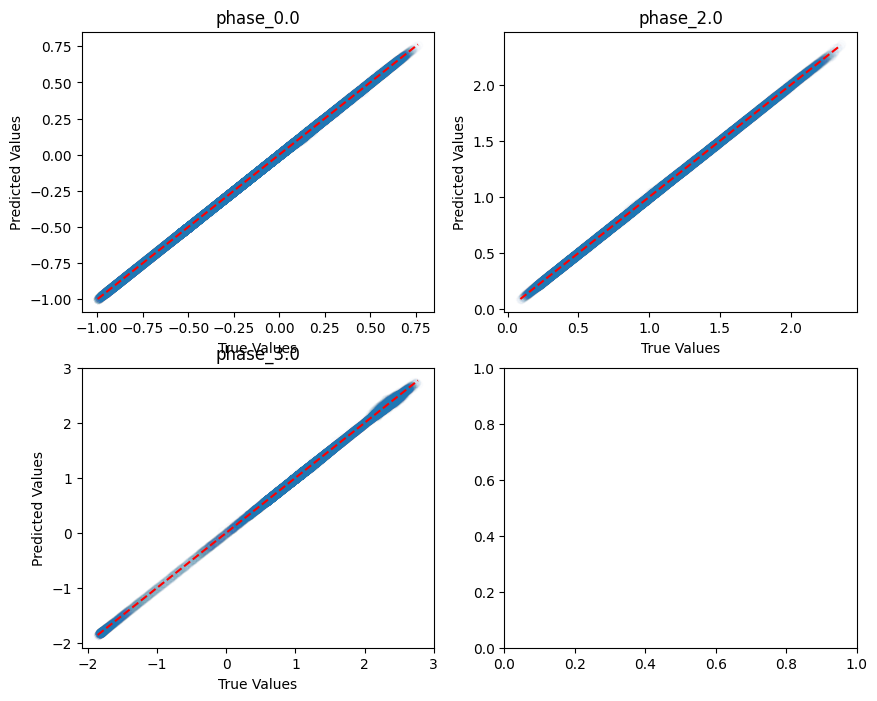

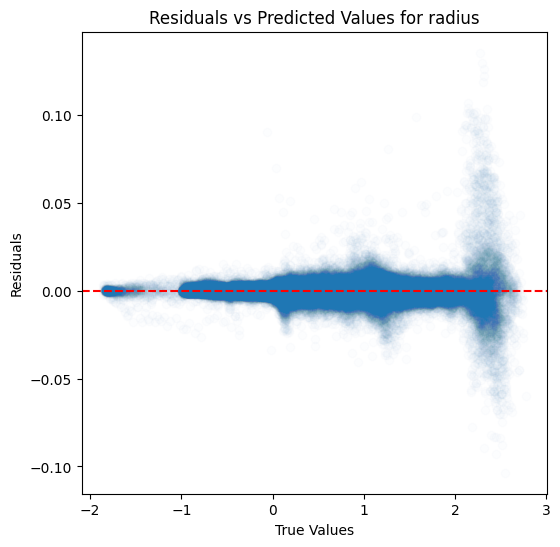

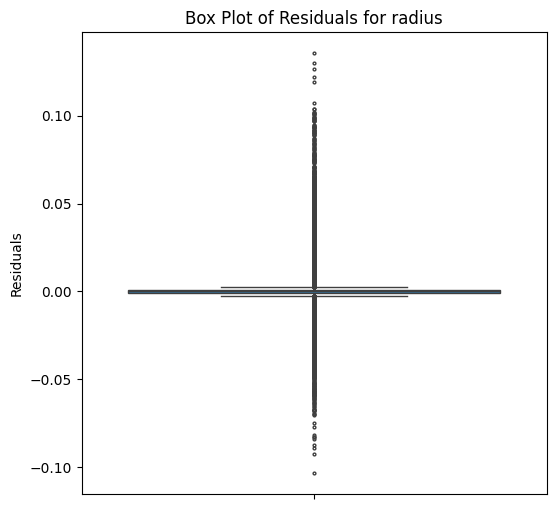

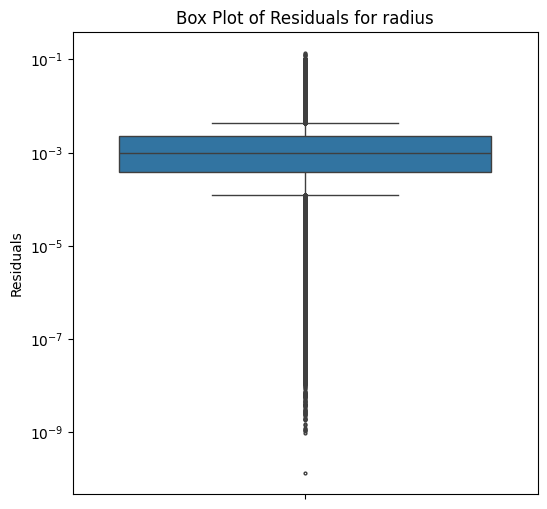

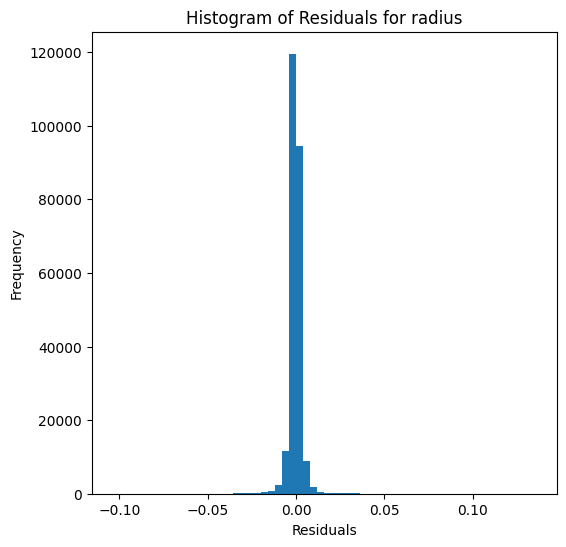

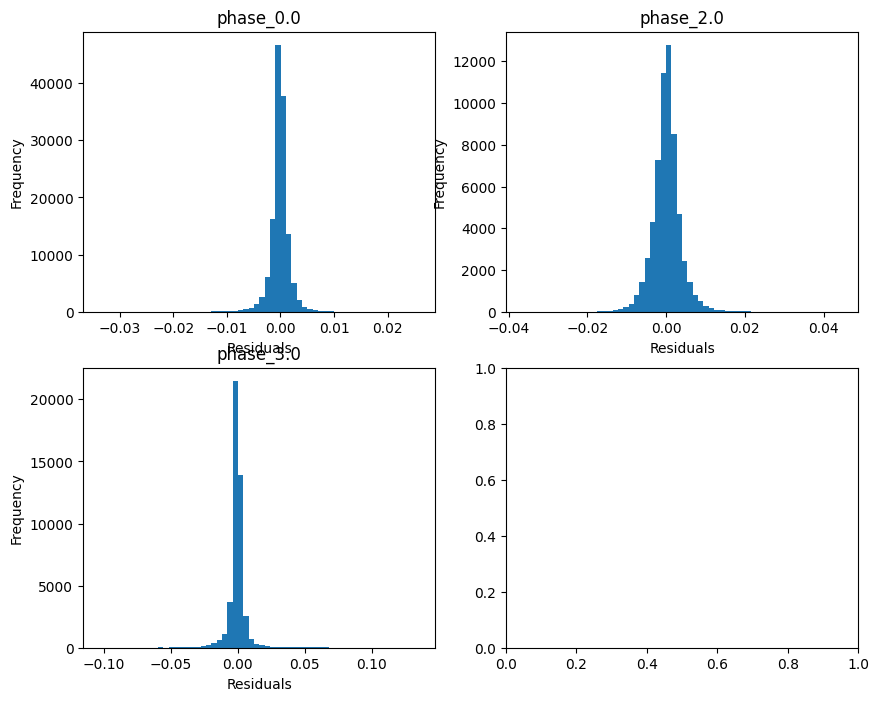

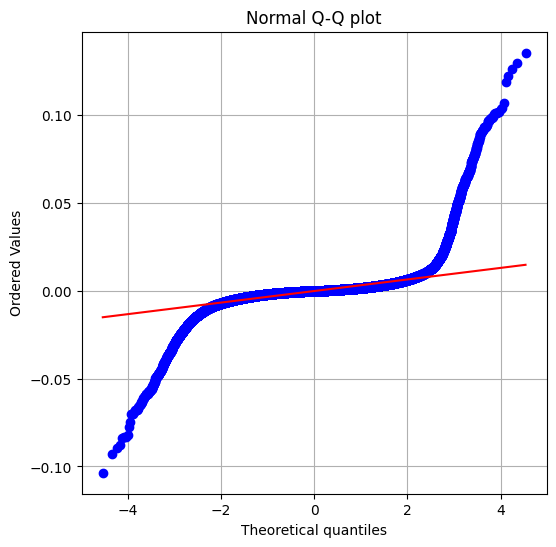

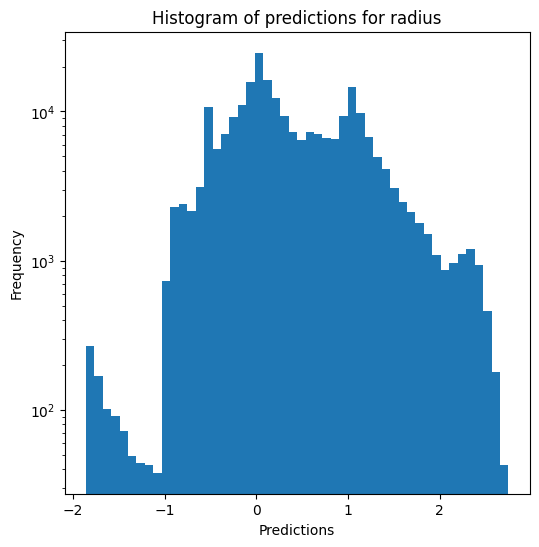

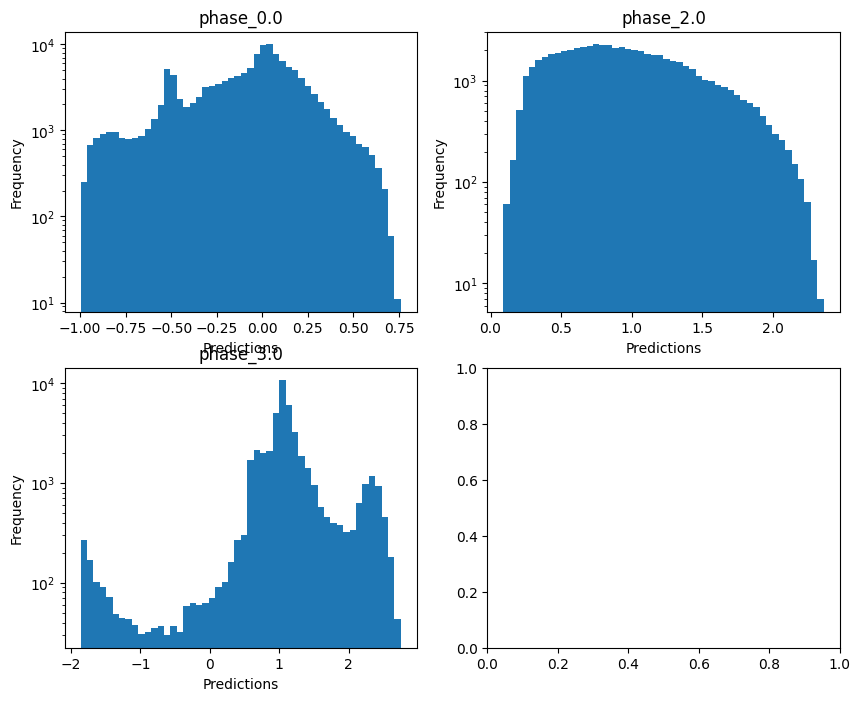

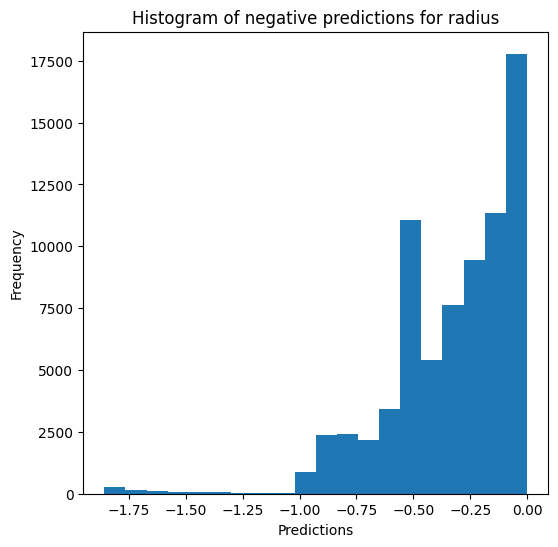

Saving results...


In [19]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True, n_jobs=5)

### XGBoost

In [20]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9990403957488978
  RMSE :  0.023363529700188942
  MAE :  0.01561878702027606
  MedAE :  0.010246877570266266
  CORR :  0.9995201456664305
  MAX_ER :  0.33286654519153314
  Percentiles : 
    75th percentile :  0.020285372650854727
    90th percentile :  0.03558909393184279
    95th percentile :  0.049253324101864816
    99th percentile :  0.0836813210331922

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.999225961655845
  RMSE :  0.017420504143439753
  MAE :  0.011962832958118098
  MedAE :  0.0081628820130073
  CORR :  0.9996379383407658
  MAX_ER :  0.17315979871153675
  Percentiles : 
    75th percentile :  0.015884393248967177
    90th percentile :  0.026804752774363116
    95th percentile :  0.03578994245827338
    99th percentile 

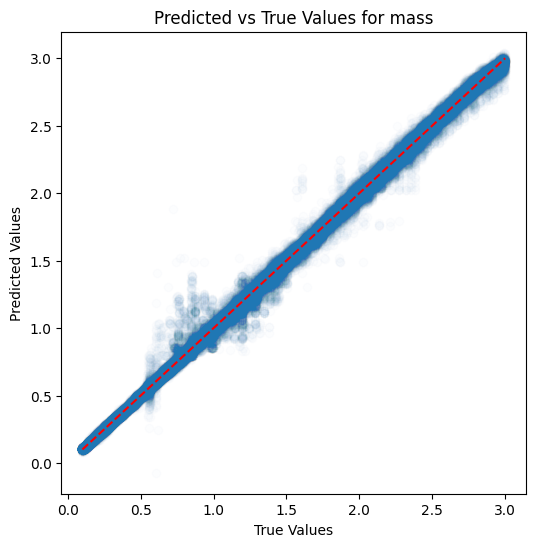

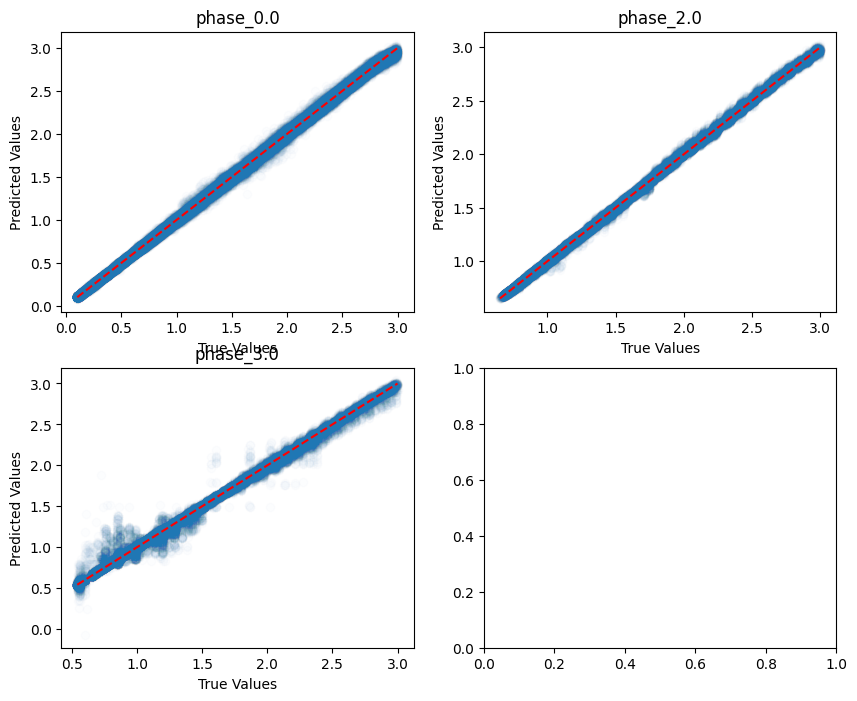

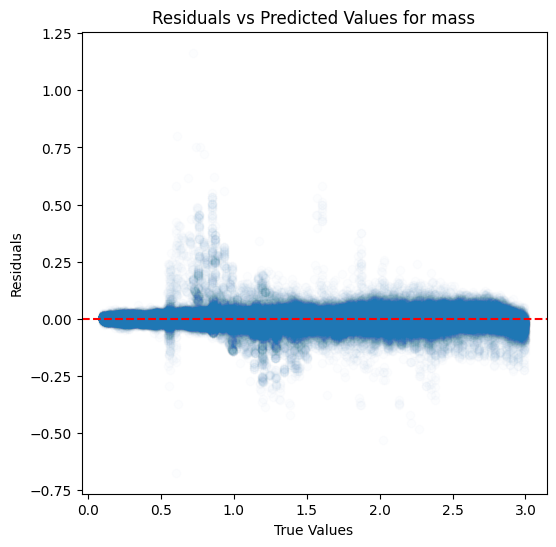

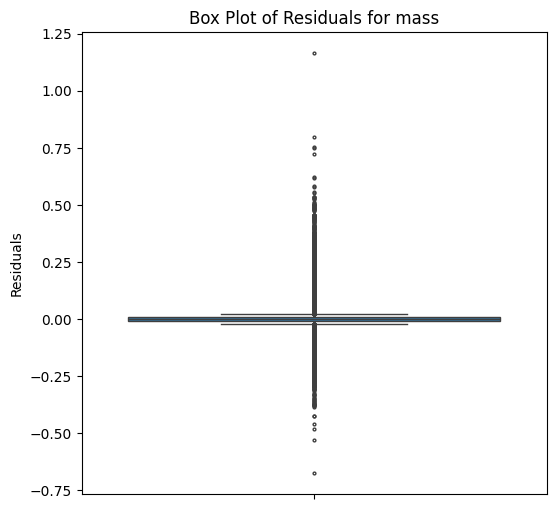

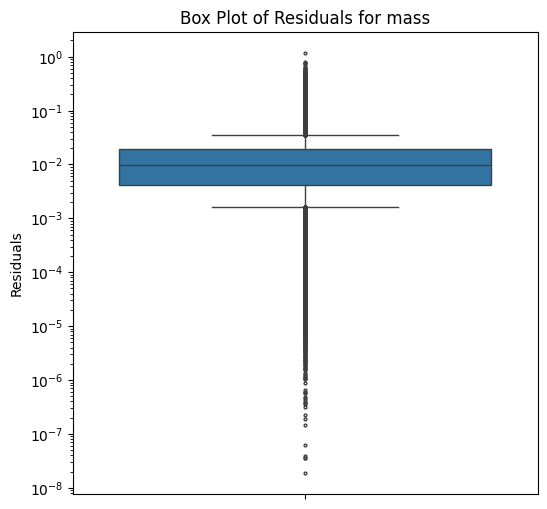

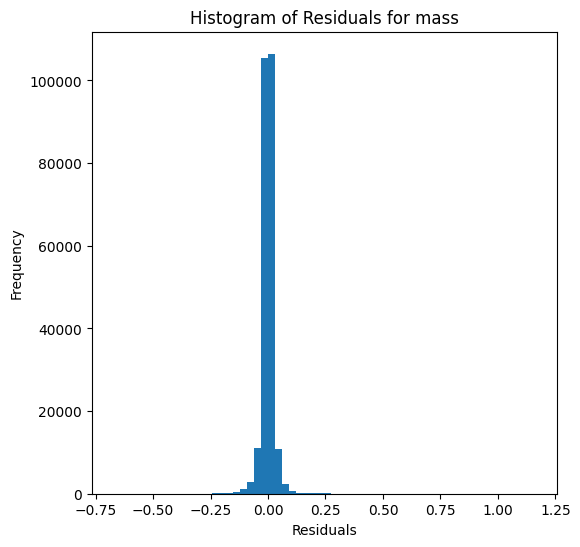

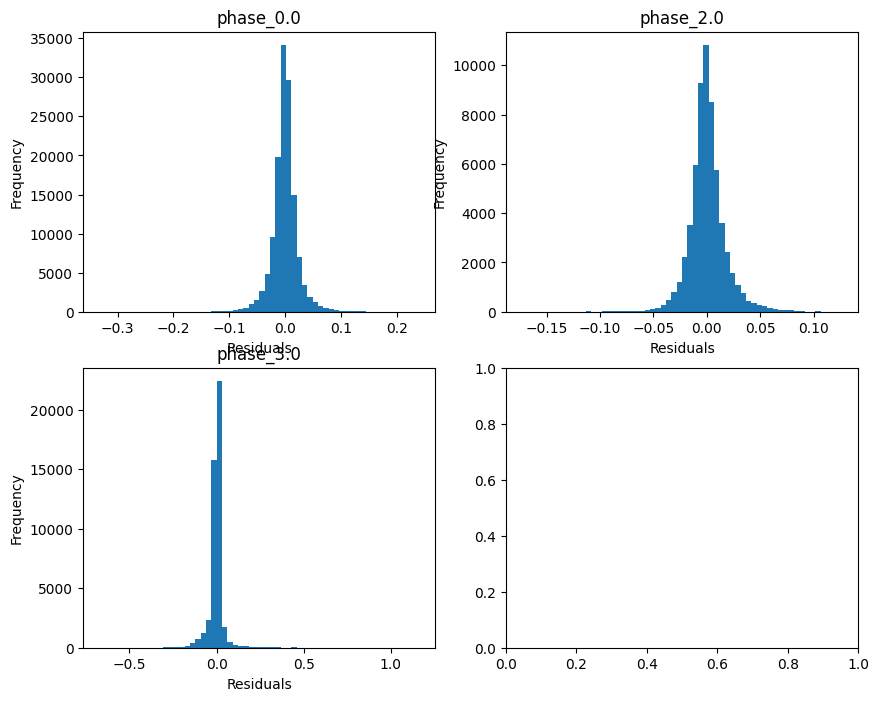

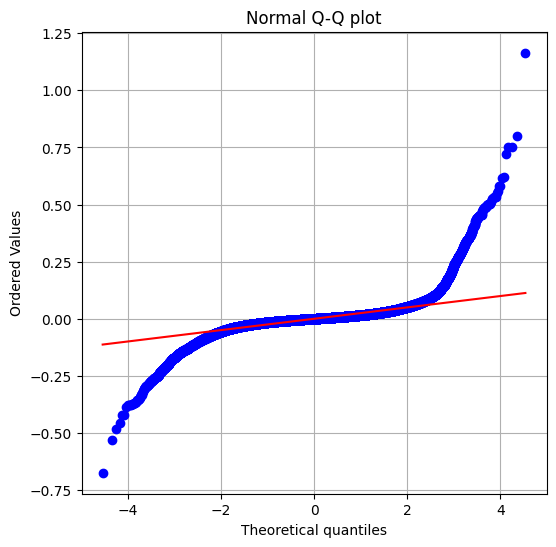

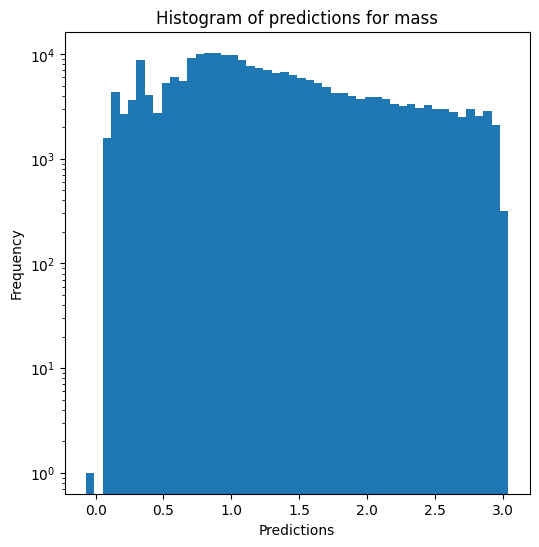

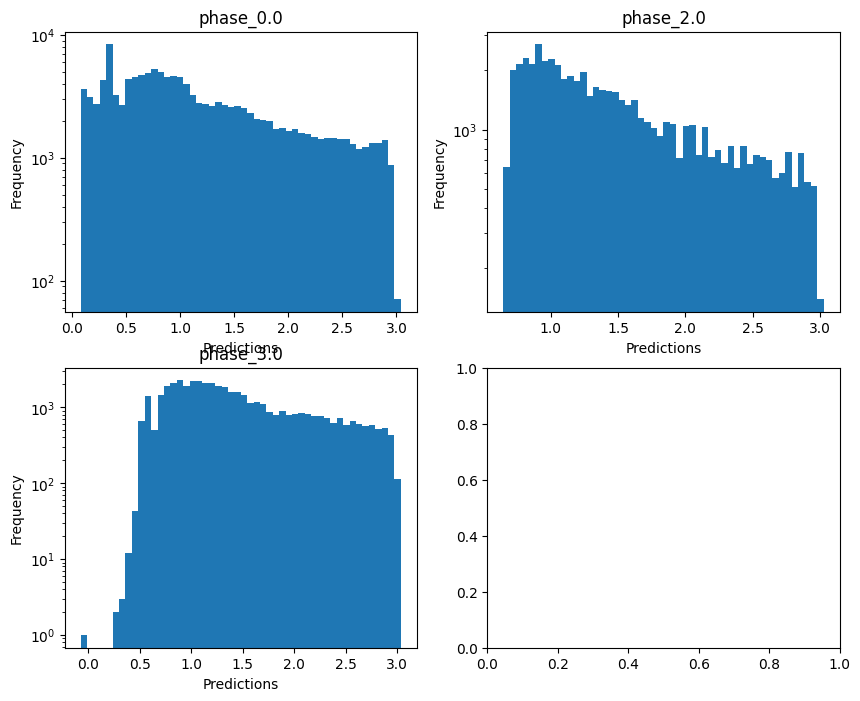

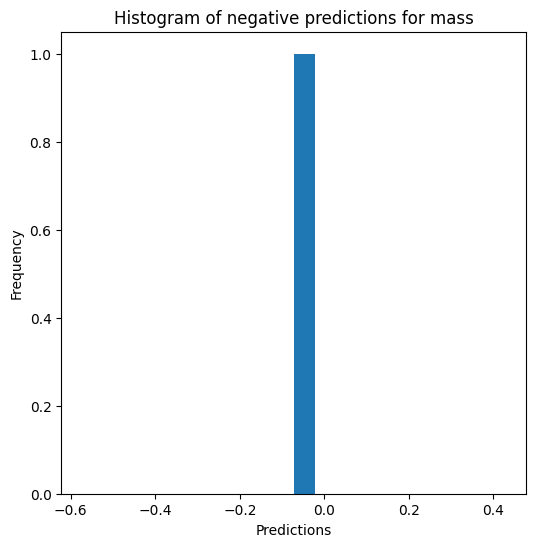


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 0.7629161677552769
  RVE :  0.9995942168068729
  RMSE :  0.006423854127584885
  MAE :  0.004873807675144647
  MedAE :  0.0038186750928417
  CORR :  0.9997970884152511
  MAX_ER :  0.14346735662654883
  Percentiles : 
    75th percentile :  0.006803757278435053
    90th percentile :  0.01039393003655371
    95th percentile :  0.013076098192491233
    99th percentile :  0.018895628299670585

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.353416446984946
  RVE :  0.9995453399672748
  RMSE :  0.009826801089903366
  MAE :  0.007534879406329916
  MedAE :  0.005998065347735615
  CORR :  0.9997726819919364
  MAX_ER :  0.0587070618717922
  Percentiles : 
    75th percentile :  0.010523218893729647
    90th percentile :  0.015980513490115644
    95th percentile :  0.019866312207103887
    99th percentile :  0.02873104571121647

radius results for the

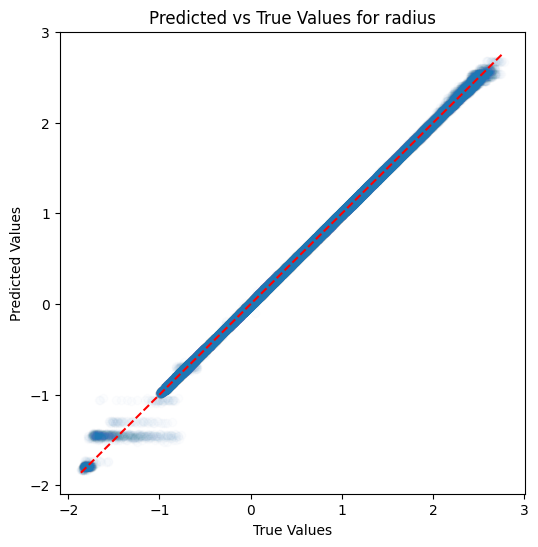

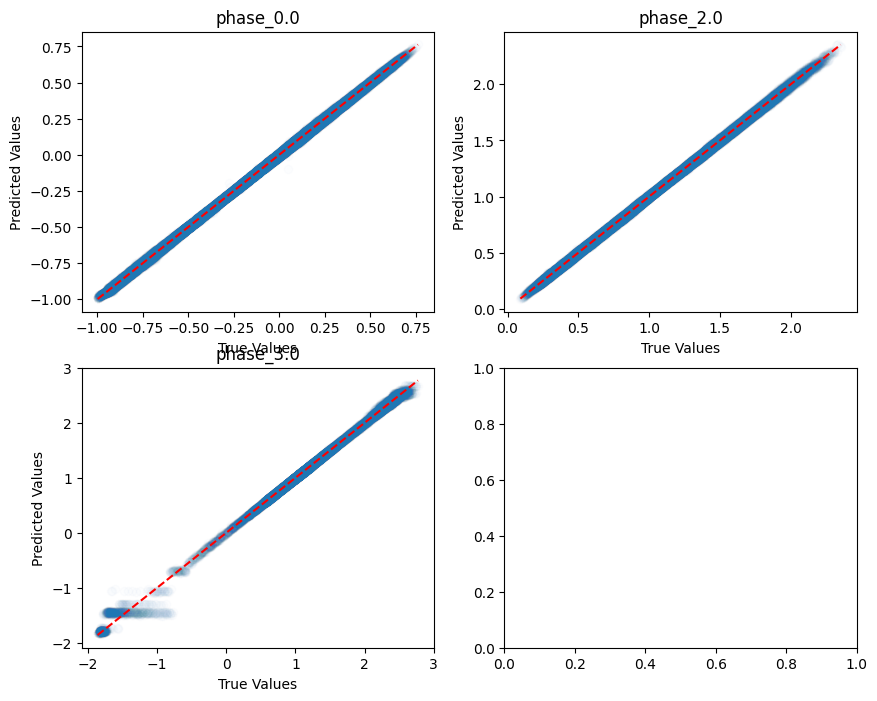

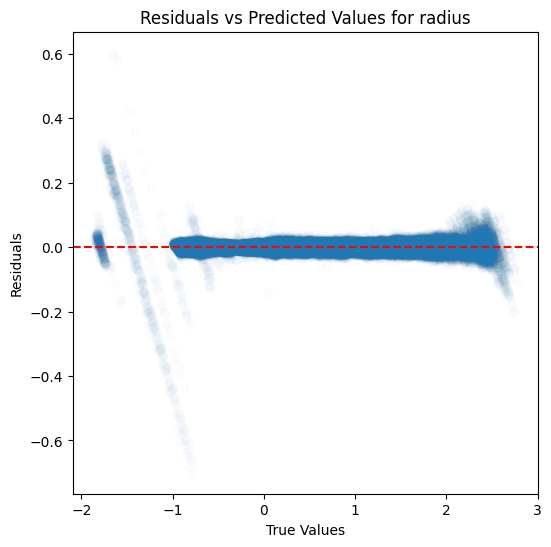

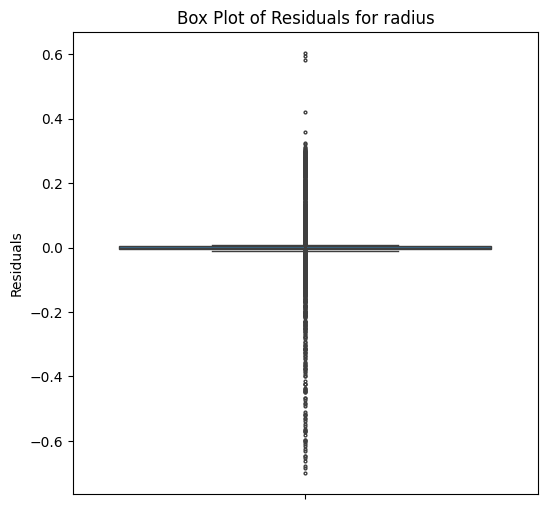

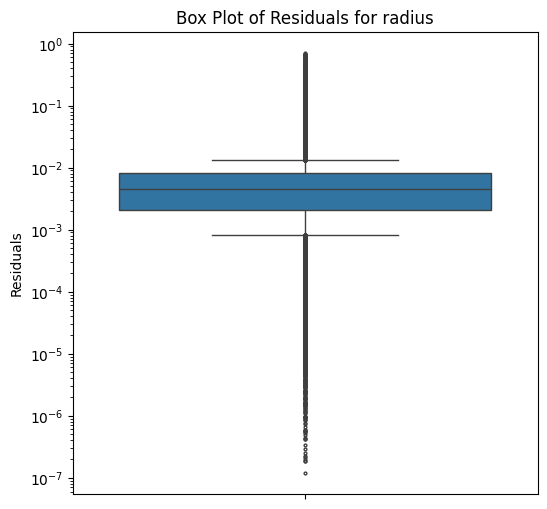

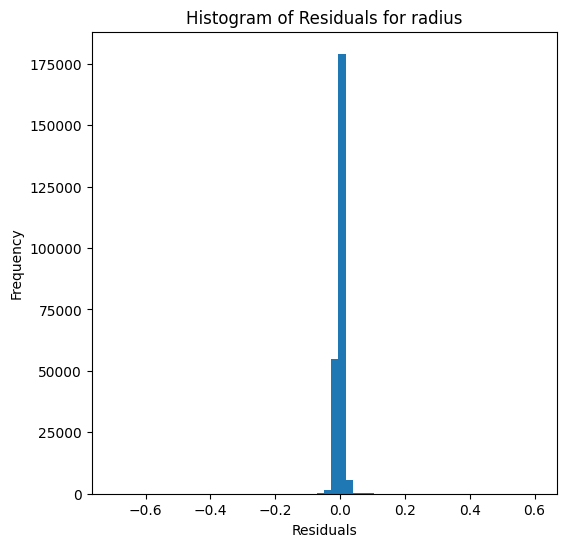

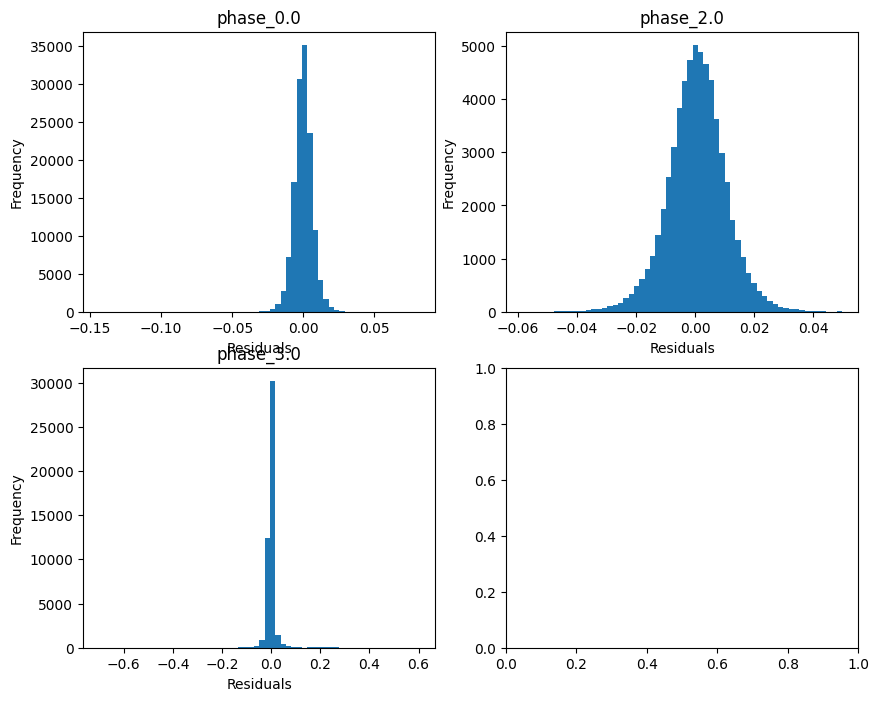

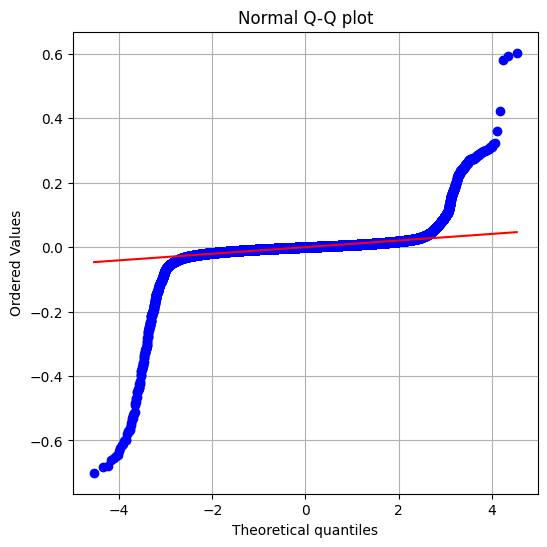

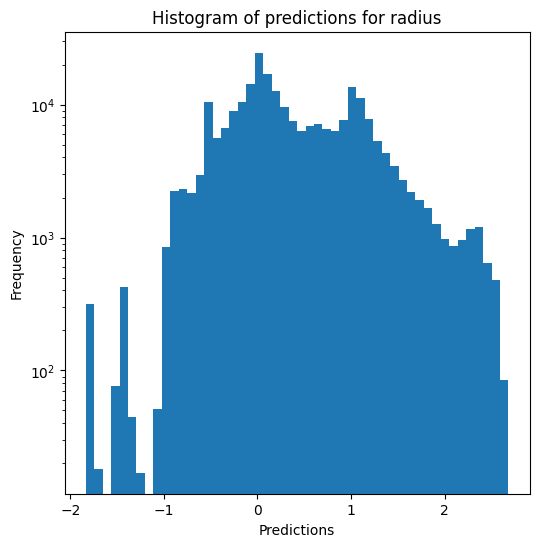

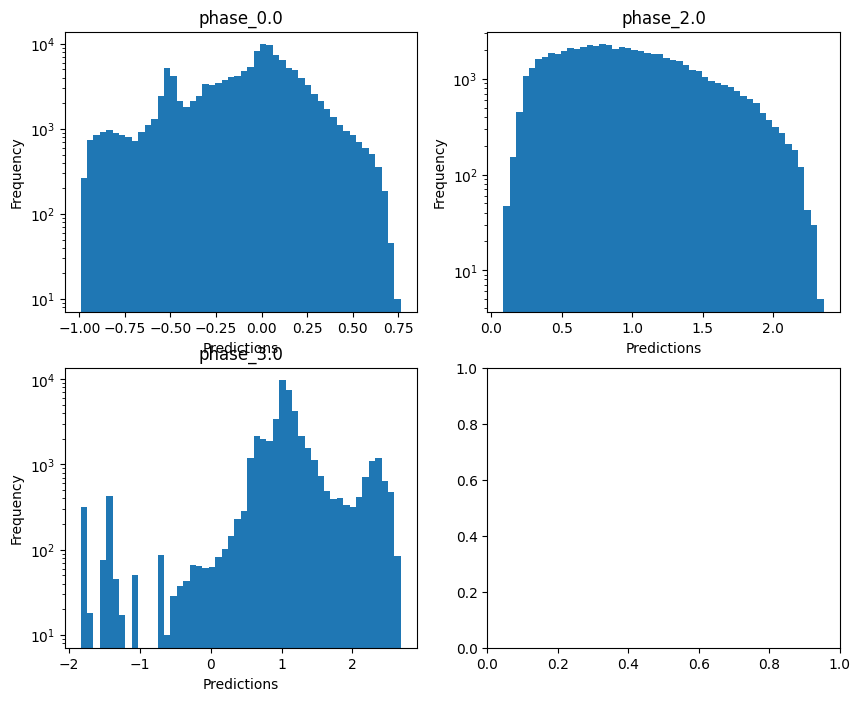

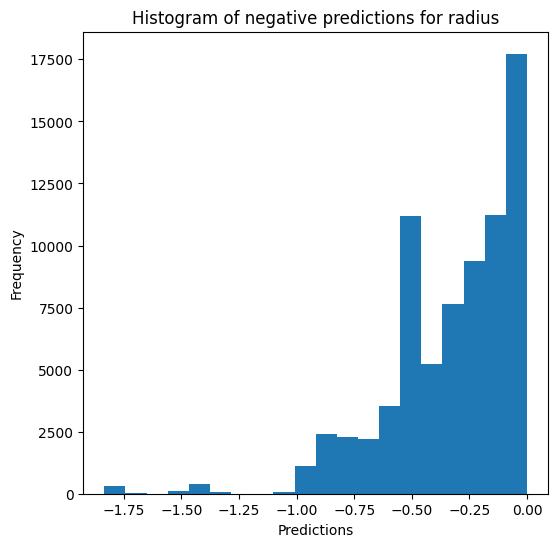

Saving results...


In [21]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True, n_jobs=5)

### Multi-layer perceptron

In [22]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9982370025646433
  RMSE :  0.0322376724352715
  MAE :  0.021222096159887786
  MedAE :  0.014953144263897489
  CORR :  0.9991181560916915
  MAX_ER :  0.4656359153324776
  Percentiles : 
    75th percentile :  0.027356016729777055
    90th percentile :  0.044677770207909084
    95th percentile :  0.060671837888578196
    99th percentile :  0.11131366437338136

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.995291571916788
  RMSE :  0.04347468113678617
  MAE :  0.03303430572775442
  MedAE :  0.02614850301189242
  CORR :  0.9976529594265796
  MAX_ER :  0.24497779297832079
  Percentiles : 
    75th percentile :  0.046729551929143076
    90th percentile :  0.06919701916414067
    95th percentile :  0.08312667139120977
   

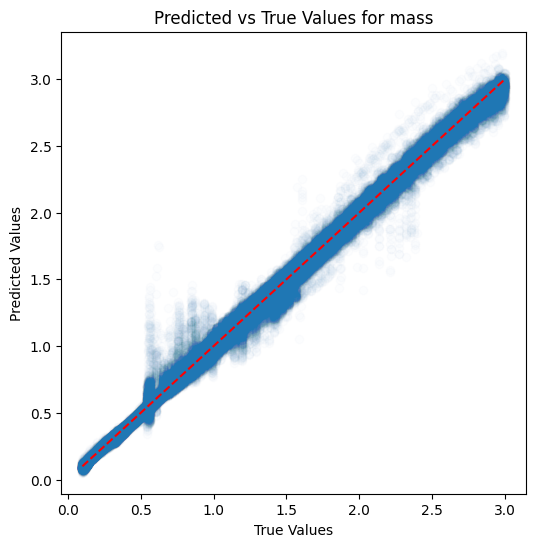

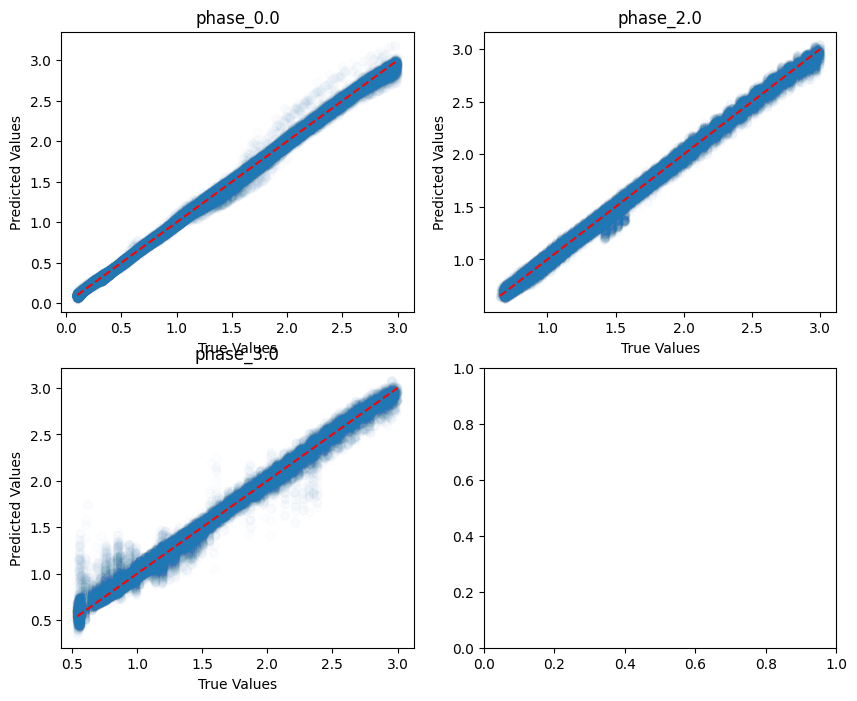

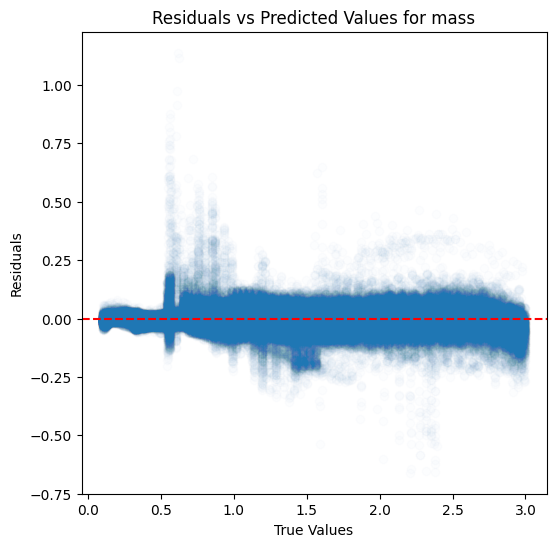

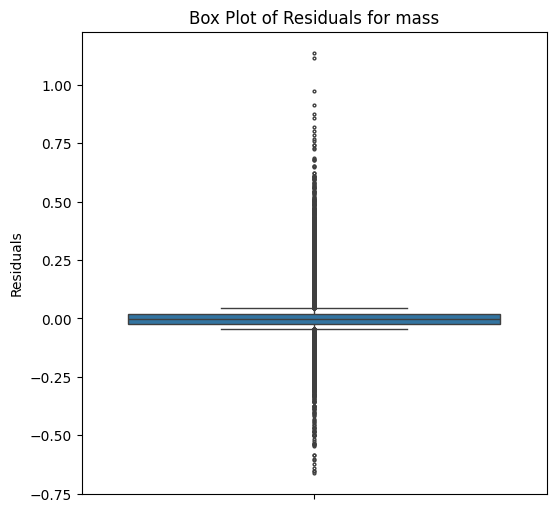

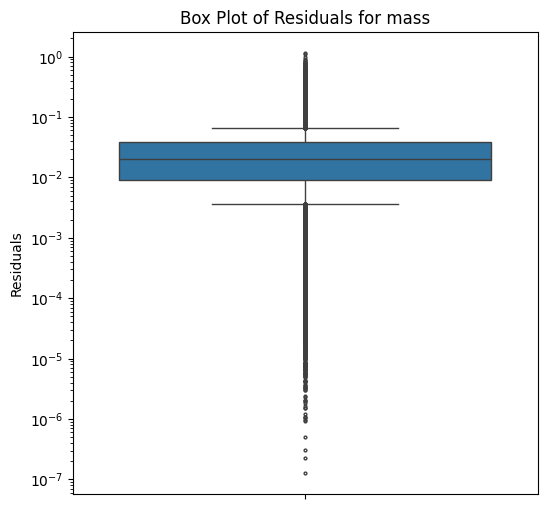

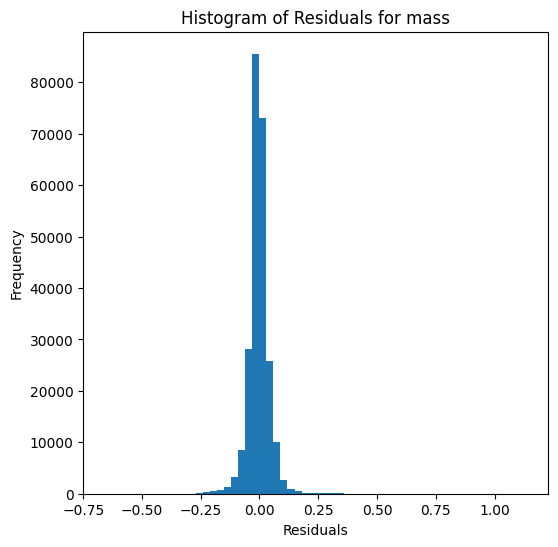

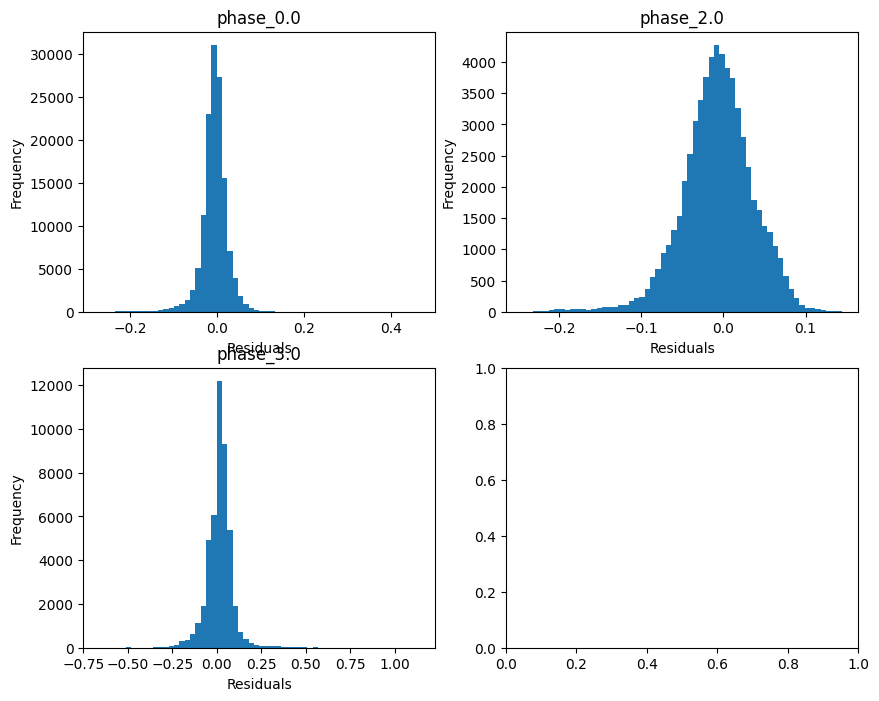

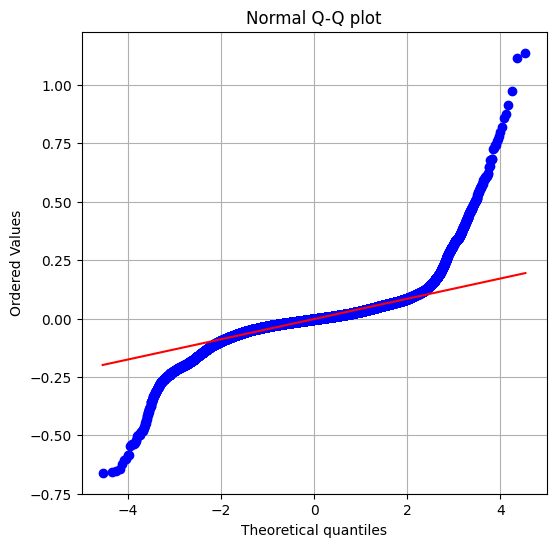

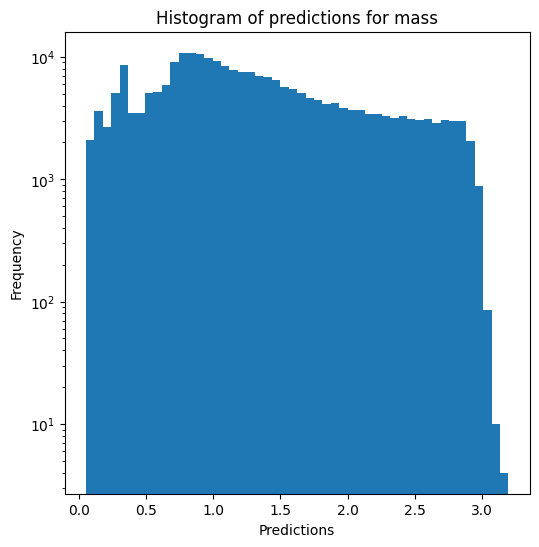

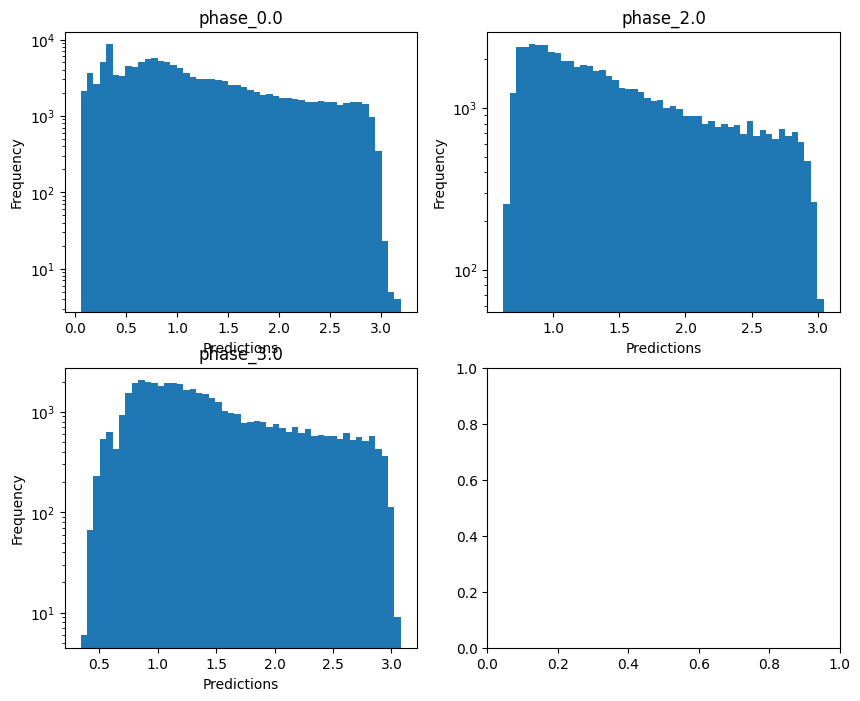


radius results for the phase category with a value of 0.0
  value range :  -0.9974234436680278 - 0.7629161677552769
  RVE :  0.9988881540732915
  RMSE :  0.010899915109169623
  MAE :  0.008418232147510444
  MedAE :  0.006831431521156811
  CORR :  0.9994442842217262
  MAX_ER :  0.059911188425952
  Percentiles : 
    75th percentile :  0.011791043331701882
    90th percentile :  0.017617756008221904
    95th percentile :  0.021879559100683395
    99th percentile :  0.03204563912541368

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.353416446984946
  RVE :  0.9991611174957181
  RMSE :  0.014736131799820456
  MAE :  0.011558274933319979
  MedAE :  0.009501594815213621
  CORR :  0.9995808035587692
  MAX_ER :  0.06752888090148179
  Percentiles : 
    75th percentile :  0.016571273449536184
    90th percentile :  0.024657884471284364
    95th percentile :  0.029504138212514186
    99th percentile :  0.038692544085485114

radius results for t

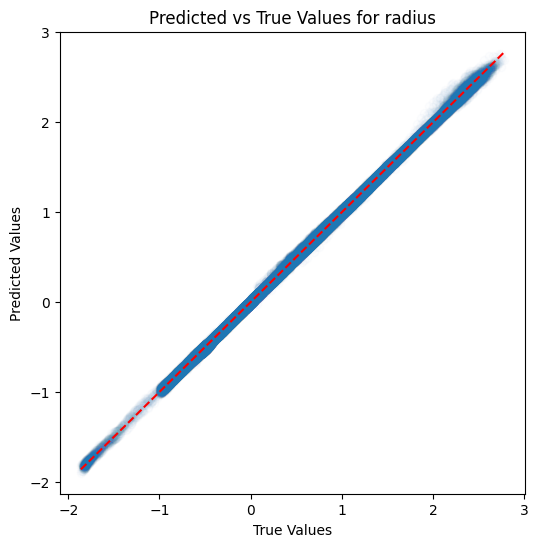

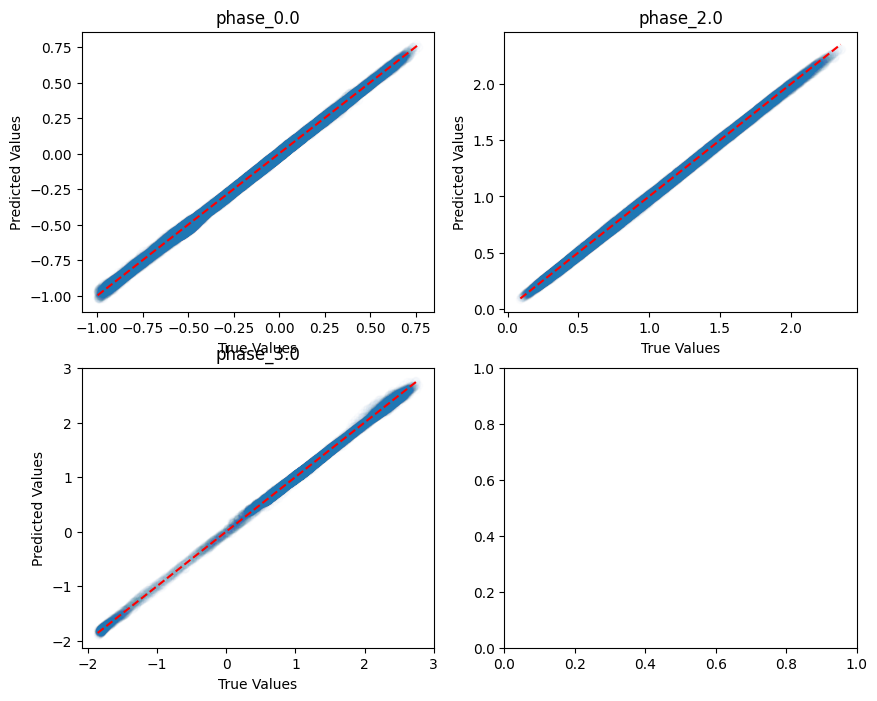

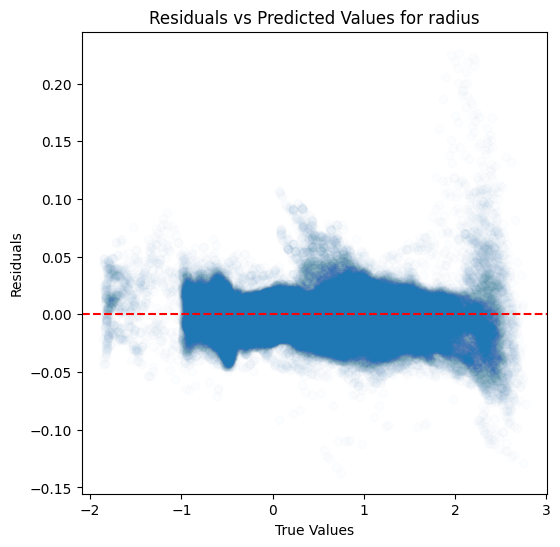

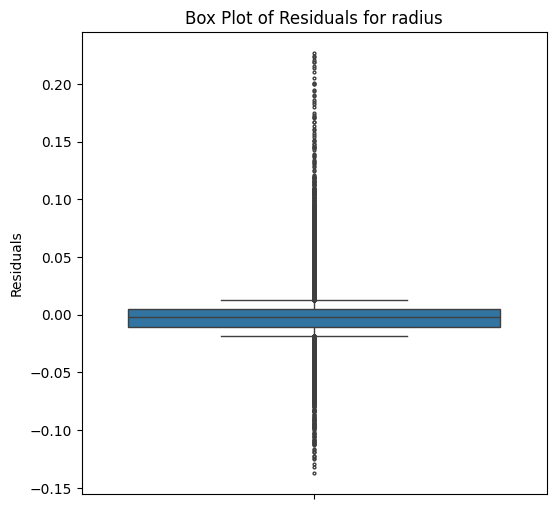

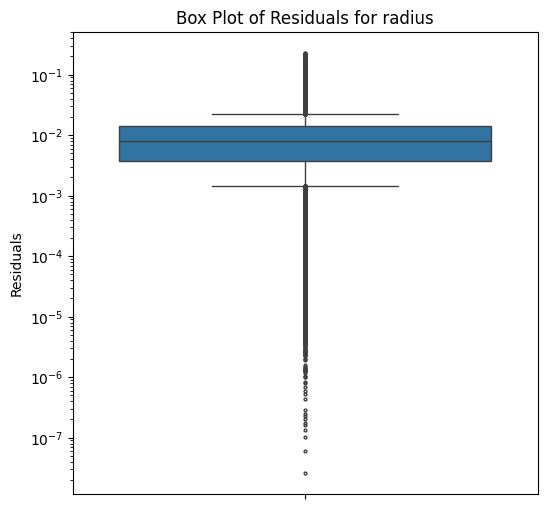

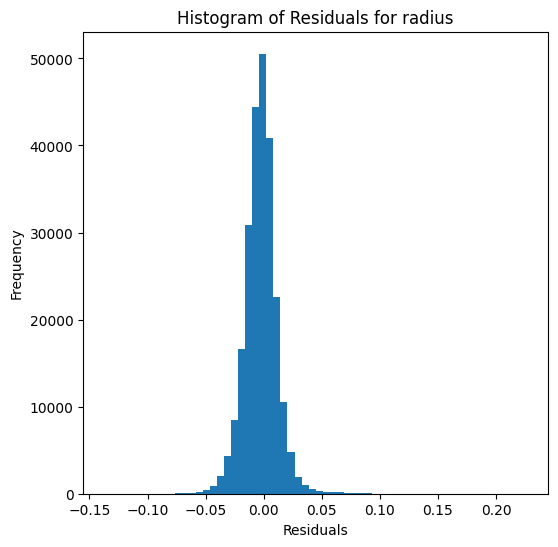

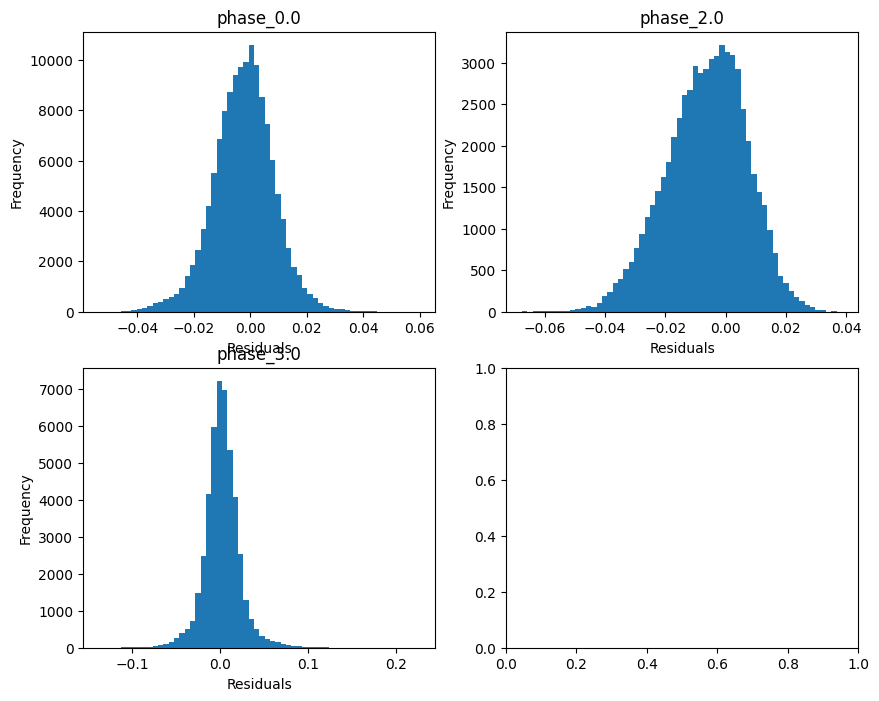

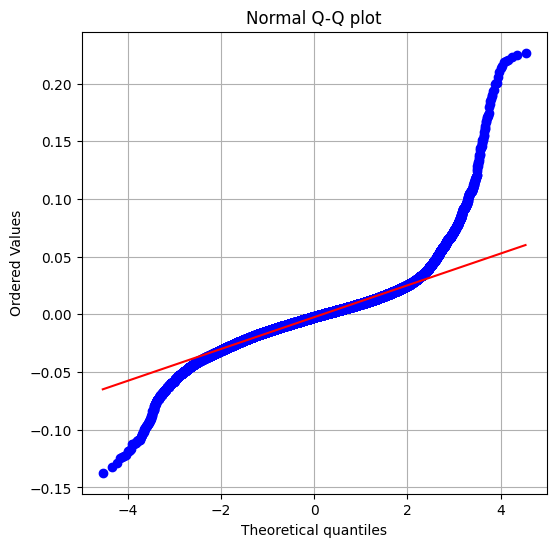

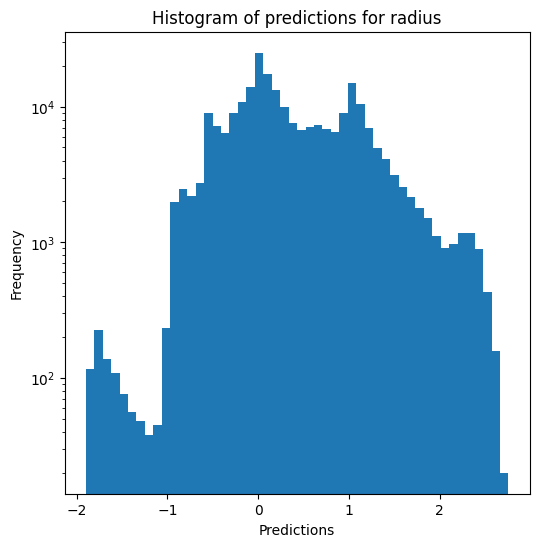

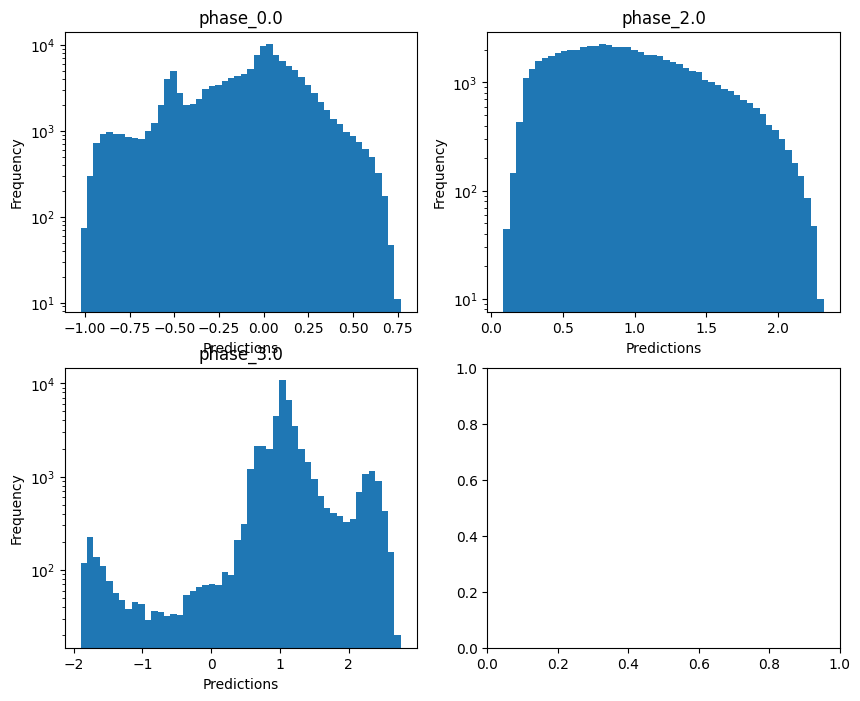

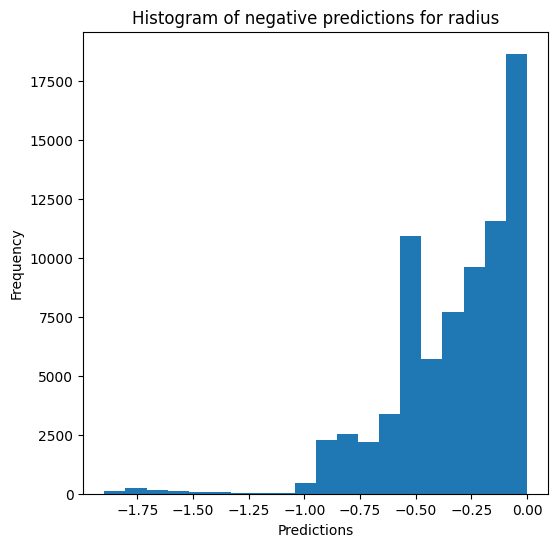

Saving results...


In [23]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=False, use_preds=True, save=True, show=True, 
                                     hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)